In [263]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch, ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib import gridspec
from scipy.spatial import Voronoi, cKDTree
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import itertools

from math import isnan
from sklearn.neighbors import NearestNeighbors

import umap
from umap.umap_ import nearest_neighbors
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
import hdbscan
import leidenalg as la

import igraph as ig

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.cluster import v_measure_score, completeness_score, homogeneity_score
from sklearn.metrics import adjusted_rand_score, silhouette_score, silhouette_samples

import datetime
import pickle

In [264]:
sns.set_theme(style="ticks", font_scale=1.6)
CALL_TYPE_COLORS = {'alarm': (0.2823529411764706, 0.47058823529411764, 0.8156862745098039), 
                    'contact': (0.9333333333333333, 0.5215686274509804, 0.2901960784313726), 
                    'departure': (0.41568627450980394, 0.8, 0.39215686274509803), 
                    'distance': (0.8392156862745098, 0.37254901960784315, 0.37254901960784315), 
                    'recruitment': (0.5843137254901961, 0.4235294117647059, 0.7058823529411765), 
                    'triumph': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882)}
DOT_SIZE = 10
ALPHA = .6

In [265]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Functions

In [266]:
def create_representations_subdf_and_scale(
    full_df, 
    column_name, 
    column_names=["Call Type", "Track ID", "Goose ID"],
    var_threshold=1e-4
):
    column_names_new_df = column_names.copy()
    subset_list = []

    # Flatten each row's feature array into a single row vector
    for _, row in full_df.iterrows():
        subset_list.append([row["Call Type"], row["Track ID"], row["Goose ID"], *row[column_name].flatten()])

    # Add feature index columns
    for i in range(len(full_df.iloc[0][column_name].flatten())):
        column_names_new_df.append(i)

    # Build dataframe
    subset_df = pd.DataFrame(subset_list, columns=column_names_new_df)

    # Extract only the numeric feature part
    X = subset_df.drop(columns=column_names).values

    # Drop near-constant columns (to remove padding artifacts)
    selector = VarianceThreshold(threshold=var_threshold)
    X = selector.fit_transform(X)

    # Scale features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, subset_df


In [267]:
def resample_subset(subset_size, df):
    subsample_sizes = {
        'recruitment': subset_size,
        'contact': subset_size,
        'departure': subset_size,
        'distance': subset_size,
        'triumph': subset_size,
        'alarm': subset_size
    }

    def subsample_group(group):
        call_type = group.name  
        target_size = subsample_sizes.get(call_type, 0)  # Default to 0 if missing

        if len(group) > target_size:
            return group.sample(n=target_size, random_state=RANDOM_SEED)
        return group  # Return full group if it's already smaller than the target size
    
    return df.groupby('Call Type', group_keys=False)[df.columns.tolist()].apply(subsample_group)

In [268]:
def hopkins(X, random_seed):
    """
    Computes Hopkins statistic to avaluate clustering tendency of the dataset.
    
    Parameters:
        X (np.ndarray): The dataset to assess (n_samples, n_features).
        random_seed (int): Seed for random number generation for permutation.
    
    Returns:
        float: The Hopkins statistic (0 to 1). Values closer to 1 indicate clusters, 
               and values closer to 0 indicate uniform distribution.
    
    adapted from https://datascience.stackexchange.com/questions/14142/cluster-tendency-using-hopkins-statistic-implementation-in-python and https://matevzkunaver.wordpress.com/2017/06/20/hopkins-test-for-cluster-tendency/ accessed November 2024
    """
    # set seeds again to ensure 
    np.random.seed(random_seed)
    random.seed(random_seed)

    d = X.shape[1]
    n = len(X) # rows
    m = int(0.07 * n) # proportion of random subset
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
 
    rand_X = random.sample(range(0, n, 1), m)
 
    uid = []
    wid = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(np.random.uniform(np.amin(X,axis=0), np.amax(X,axis=0), d).reshape(1, -1), 2, return_distance=True)
        uid.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wid.append(w_dist[0][1])
 
    H = sum(uid) / (sum(uid) + sum(wid))
    if isnan(H):
        print(uid, wid)
        H = 0

    return H

In [269]:
def silhouette_on_graph(graph, memberships):
    labels = np.array(memberships)
    dist_matrix = np.array(graph.distances())
    return np.mean(silhouette_samples(dist_matrix, labels, metric="precomputed"))

In [270]:
def display_nearest_neighbours(nn_graph, df, n_examples=5, n_neighbors=15, randomize=True, seed=None):
    nn_indices = nn_graph[0]

    # choose random query indices
    if randomize:
        rng = np.random.default_rng(seed)
        example_indices = rng.choice(len(df), size=n_examples, replace=False)
    else:
        example_indices = np.arange(n_examples)

    fig, axs = plt.subplots(
        nrows=n_examples, ncols=n_neighbors+1,  # +1 for query itself
        figsize=((n_neighbors+1)*1.2, n_examples*1.2),
        squeeze=False
    )

    for row, i in enumerate(example_indices):
        # plot query spectrogram in first column
        axs[row, 0].matshow(
            df.iloc[i]["log_padded_spectrogram"],
            origin="lower", cmap="binary", aspect="auto"
        )
        axs[row, 0].axis("off")

        # plot its nearest neighbors
        for j in range(n_neighbors):
            idx = nn_indices[i, j]
            axs[row, j+1].matshow(
                df.iloc[idx]["log_padded_spectrogram"],
                origin="lower", cmap="binary", aspect="auto"
            )
            axs[row, j+1].axis("off")

    plt.tight_layout()
    plt.show()


In [271]:
def scatter_projections(
    syllables=None,
    projection=None,
    labels=None,
    ax=None,
    figsize=(10, 10),
    alpha=0.1,
    s=1,
    color="k",
    color_palette="tab20",
    categorical_labels=True,
    show_legend=True,
    tick_pos="bottom",
    tick_size=16,
    cbar_orientation="vertical",
    log_x=False,
    log_y=False,
    grey_unlabelled=True,
    fig=None,
    colornorm=False,
    rasterized=True,
    equalize_axes=True,
    print_lab_dict=False,  # prints color scheme
    lab_dict=CALL_TYPE_COLORS,
):
    """ 
    creates a scatterplot of syllables using some projection
    From Sainburg et al. 2020: https://github.com/timsainb/avgn_paper/blob/V2/avgn/visualization/projections.py
    """
    if projection is None and syllables is None:
            raise ValueError("Either syllables or projections must be passed")

    # color labels
    if labels is not None:
        if categorical_labels:
            if lab_dict is None:
                if (color_palette == "tab10") & (len(np.unique(labels)) < 10):
                    pal = sns.color_palette(color_palette, n_colors=10)
                    pal = np.array(pal)[
                        np.linspace(0, 9, len(np.unique(labels))).astype("int")
                    ]
                else:
                    pal = sns.color_palette(color_palette, n_colors=len(np.unique(labels)))
                lab_dict = {lab: pal[i] for i, lab in enumerate(np.unique(labels))}

            if grey_unlabelled and -1 in lab_dict:
                lab_dict[-1] = [0.95, 0.95, 0.95, 1.0]

            if print_lab_dict:
                print(lab_dict)

            colors = np.array([lab_dict[i] for i in labels])
        else:
            colors = labels  # continuous case
    else:
        colors = color

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if colornorm:
        norm = LogNorm()
    else:
        norm = None

    if categorical_labels or labels is None:
        ax.scatter(
            projection[:, 0],
            projection[:, 1],
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            color=colors,
            norm=norm,
        )

    else:
        cmin = np.quantile(labels, 0.01)
        cmax = np.quantile(labels, 0.99)
        sct = ax.scatter(
            projection[:, 0],
            projection[:, 1],
            vmin=cmin,
            vmax=cmax,
            cmap=plt.get_cmap(color_palette),
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            c=labels,
        )

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(1.5)

    if labels is not None:
        if categorical_labels == True:
            legend_elements = [
                Line2D([0], [0], marker="o", color=value, label=key)
                for key, value in lab_dict.items()
            ]
        if show_legend:
            if not categorical_labels:
                if cbar_orientation == "horizontal":
                    axins1 = inset_axes(
                        ax,
                        width="50%",  # width = 50% of parent_bbox width
                        height="5%",  # height : 5%
                        loc="upper left",
                    )
                    # cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation

                else:
                    axins1 = inset_axes(
                        ax,
                        width="5%",  # width = 50% of parent_bbox width
                        height="50%",  # height : 5%
                        loc="lower right",
                    )
                cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation)
                cbar.ax.tick_params(labelsize=tick_size)
                axins1.xaxis.set_ticks_position(tick_pos)
            else:
                ax.legend(handles=legend_elements)
    if equalize_axes:
        ax.axis("equal")
    return ax

def scatter_spec(
    z,
    specs,
    column_size=10,
    pal_color="hls",
    matshow_kwargs={"cmap": plt.cm.Greys},
    scatter_kwargs={"alpha": 0.5, "s": 1},
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 1},
    color_points=False,
    figsize=(10, 10),
    range_pad=0.1,
    x_range=None,
    y_range=None,
    enlarge_points=0,
    draw_lines=True,
    n_subset=-1,
    ax=None,
    show_scatter=True,
    border_line_width=1,
    img_origin="lower",
):
    n_columns = column_size * 4 - 4
    pal = sns.color_palette(pal_color, n_colors=n_columns)

    if ax is None:
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(column_size, column_size)
        main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])

    else:
        fig = ax.figure

       # get subplot bbox in figure coordinates
        bbox = ax.get_position()
        width = bbox.width
        height = bbox.height
        side = min(width, height)

        # center a square in subplot
        cx = bbox.x0 + width/2
        cy = bbox.y0 + height/2
        square_bbox = [cx - side/2, cy - side/2, side, side]

        # main_ax remains the user-passed ax
        main_ax.set_position(square_bbox)

        # now build the ring of small axes manually in figure coordinates
        n_thumbs = len(specs)  # or column_size*4-4
        for i, spec in enumerate(specs):
            # compute row/col in ring as before
            row, col = ...  # same as original logic
            x0 = square_bbox[0] + (col / column_size) * side
            y0 = square_bbox[1] + (row / column_size) * side
            ax_small = fig.add_axes([x0, y0, side/column_size, side/column_size])
            ax_small.matshow(spec, origin="lower", cmap="binary")
            ax_small.set_xticks([])
            ax_small.set_yticks([])
            for spine in ax_small.spines.values():
                spine.set_edgecolor('grey')
                spine.set_linewidth(1.5)

    fig.patch.set_alpha(0)

    # Determine plotting range
    if x_range is None and y_range is None:
        z_arr = np.vstack(z)
        x_sorted = np.sort(z_arr[:, 0])
        y_sorted = np.sort(z_arr[:, 1])
        xmin, xmax = x_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        ymin, ymax = y_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        xmin -= (xmax - xmin) * range_pad
        xmax += (xmax - xmin) * range_pad
        ymin -= (ymax - ymin) * range_pad
        ymax += (ymax - ymin) * range_pad
    else:
        xmin, xmax = x_range
        ymin, ymax = y_range

    x_block = (xmax - xmin) / column_size
    y_block = (ymax - ymin) / column_size

    # Filter to points within range
    z = np.array(z)
    mask = (z[:, 0] > xmin) & (z[:, 1] > ymin) & (z[:, 0] < xmax) & (z[:, 1] < ymax)

    if "labels" in scatter_kwargs:
        scatter_kwargs["labels"] = np.array(scatter_kwargs["labels"])[mask]
    specs = np.array(specs)[mask]
    z = z[mask]

    # Respect n_subset only when positive
    if n_subset is not None and n_subset > 0:
        z = z[:n_subset]
        specs = specs[:n_subset]
        if "labels" in scatter_kwargs:
            scatter_kwargs["labels"] = scatter_kwargs["labels"][:n_subset]

    # # Prepare the main axis
    # main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])
    if show_scatter and len(z) > 0:
        scatter_projections(projection=z, ax=main_ax, fig=fig, **scatter_kwargs)

    # Build the ring of small axes
    axs = {}
    for column in range(n_columns):
        # decide row/col on the ring
        if column < column_size:
            row = 0
            col = column
        elif (column >= column_size) and (column < (column_size * 2) - 1):
            row = column - column_size + 1
            col = column_size - 1
        elif (column >= ((column_size * 2) - 1)) and (column < (column_size * 3 - 2)):
            row = column_size - 1
            col = column_size - 3 - (column - column_size * 2)
        else:
            row = n_columns - column
            col = 0

        axs[column] = {"ax": fig.add_subplot(gs[row, col]), "col": col, "row": row}

        # geometric center for this small axis (in data coords)
        xpos = xmin + x_block * col + x_block / 2
        ypos = ymax - y_block * row - y_block / 2
        axs[column]["xpos"] = xpos
        axs[column]["ypos"] = ypos

    main_ax.set_xlim([xmin, xmax])
    main_ax.set_ylim([ymin, ymax])
    for spine in main_ax.spines.values():
            spine.set_linewidth(0)
    main_ax.patch.set_alpha(0)

    if len(z) == 0:
        gs.update(wspace=0, hspace=0)
        return fig  # nothing to connect

    # Voronoi over the ring cell centers, then assign each z-point to nearest center
    points = np.array([[axs[i]["xpos"], axs[i]["ypos"]] for i in axs.keys()])
    voronoi_kdtree = cKDTree(points)
    # index of closest cell center for each z point
    _, point_regions = voronoi_kdtree.query(z)

    # Track which z points have been used so we don't reuse the same one
    used = np.zeros(len(z), dtype=bool)
    lines_list = []

    # Loop through cells on the ring and pick a representative z point
    for key in axs.keys():
        ax_small = axs[key]["ax"]

        # pick a z point assigned to this region that hasn't been used
        in_region = np.where((point_regions == key) & (~used))[0]

        if in_region.size:
            chosen_point = np.random.choice(in_region)
        else:
            # fallback: choose nearest unused to the cell center
            center = np.array([axs[key]["xpos"], axs[key]["ypos"]])
            avail = np.where(~used)[0]
            dists = np.linalg.norm(z[avail] - center, axis=1)
            chosen_point = avail[np.argmin(dists)]

        used[chosen_point] = True

        # draw the spectrogram in the small axis
        ax_small.matshow(
            specs[chosen_point],
            origin=img_origin,
            interpolation="none",
            aspect="auto",
            **matshow_kwargs,
        )
        ax_small.set_xticks([])
        ax_small.set_yticks([])
        ax_small.patch.set_alpha(0)

        # colored borders if requested
        if color_points:
            plt.setp(ax_small.spines.values(), color=pal[key])
        for spine in ax_small.spines.values():
            spine.set_linewidth(border_line_width)

        # optionally enlarge and color the chosen main point
        if enlarge_points > 0:
            dot_color = pal[key] if color_points else "k"
            main_ax.scatter(
                [z[chosen_point, 0]],
                [z[chosen_point, 1]],
                color=dot_color,
                s=enlarge_points,
                zorder=3,
            )

        # draw dashed connection using robust transforms
        if draw_lines:
            # pick an anchor on the edge of the small subplot (in Axes coords)
            line_end_pos = [0.5, 0.5]
            if axs[key]["row"] == 0:
                line_end_pos[1] = 0
            if axs[key]["row"] == column_size - 1:
                line_end_pos[1] = 1
            if axs[key]["col"] == 0:
                line_end_pos[0] = 1
            if axs[key]["col"] == column_size - 1:
                line_end_pos[0] = 0

            con = ConnectionPatch(
                xyA=(z[chosen_point, 0], z[chosen_point, 1]),
                coordsA=main_ax.transData,          # data coords on main axis
                xyB=tuple(line_end_pos),
                coordsB=ax_small.transAxes,         # axes coords on small subplot
                axesA=main_ax,
                axesB=ax_small,
                **line_kwargs,
            )
            fig.add_artist(con)
            lines_list.append(con)

    if isinstance(gs, gridspec.GridSpec):
        gs.update(wspace=0, hspace=0)
    else:
        plt.subplots_adjust(wspace=0, hspace=0)
    return fig

In [272]:
def plot_embeddings_with_colorcoded_label(df, embeddings, label_column, plot_title, legend_title=None, show_legend=True):

    if type(label_column) != str:
        unique_labels = np.unique(label_column)
        colors = cm.nipy_spectral(label_column.astype(float) / (np.max(label_column)+1))
        #colors = sns.color_palette("muted", len(unique_labels))
        legend_patches = [Patch(color=color, label=label) for label, color in zip(unique_labels, colors)]
        
    else:
        unique_labels = df[label_column].unique()
        color_palette = sns.color_palette("muted", len(unique_labels))
        label_to_color = {label: color for label, color in zip(unique_labels, color_palette)}
        if "call" in label_column:
            legend_patches = [Patch(color=color, label=label) for label, color in CALL_TYPE_COLORS.items()]
            colors = [CALL_TYPE_COLORS[label] for label in df[label_column]]
        else:
            legend_patches = [Patch(color=color, label=label) for label, color in label_to_color.items()]
            # Assign colors to points
            colors = [label_to_color[label] for label in df[label_column]]

    # Scatter plot
    plt.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=colors,
        s=DOT_SIZE, 
        alpha=ALPHA
    )
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(plot_title, fontsize=14)

    if type(label_column) == str:
        if show_legend:
            if legend_title is None:
                legend_title = label_column

            # Legend
            plt.legend(
                handles=legend_patches,
                title=legend_title,
                fontsize=8,
                title_fontsize=10,
                loc="center left",
                bbox_to_anchor=(1.0, 0.7)
            )

    plt.show()

In [273]:
def silhouette_analysis_hdbscan(data, embeddings=None, min_sample_numbers=[1, 2, 3, 4, 5, 15, 25], plot_every_step=False, plot_best_clustering=True):
    """
    adapted from https://scikit-learn.org/1.5/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

    Performs silhouette analysis using HDBSCAN to find parameter values of min_cluster_sizes, min_sample_numbers with highest silhouette score result.

    Parameters:
        data (ndarray of shape (n_samples, n_features)): data to cluster and analyze
        optional:
            embeddings (2D ndarray): embeddings of analyzed data to plot, if not given, data is assumed to be embeddings # TODO switch data and embeddings so it actually makes sense
            plot_every_step (bool): plot results of every analysis step. default=False
            plot_best_clustering (bool): plot clustering with highest silhouette score
            
    Returns:
        max_score (float): highest silhouette score
        n (int): number of clusters where silhouette score is highest
        labels (ndarray of shape (n_samples,)): cluster labels for every data point
    """

    plot_any = False

    if embeddings is None:
        embeddings = data
        plot_any = True

    max_score, best_n, best_labels, best_params = -1, 0, None, None

    min_cluster_sizes = [int(len(data) * 0.01)]
    
    for min_size, min_samples in itertools.product(min_cluster_sizes, min_sample_numbers):
        # Initialize the clusterer with n_clusters value and a random generator
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size, 
            min_samples=min_samples, 
            prediction_data=True
            )
        cluster_labels = clusterer.fit_predict(data)

        n_clusters = clusterer.labels_.max()+1
        if n_clusters > 1:
            sil_score = silhouette_score(data, cluster_labels)

            # print(
            #     f'For min_cluster_size={min_size}, min_samples={min_samples}, n_clusters={n_clusters}: \
            #     average silhouette_score={sil_score}'
            # )

            # no centers because clusters may not be convex
            if sil_score > max_score:
                max_score = sil_score
                best_n = n_clusters
                best_labels = cluster_labels
                best_params = (min_size, min_samples)

    # print(f'\nBest parameter combination: min_cluster_size={best_params[0]}, min_samples={best_params[1]} \
    #       with {best_n} clusters and silhouette score: {max_score}')

    if plot_best_clustering and plot_any:
        plot_embeddings_with_colorcoded_label(data, embeddings, best_labels, "HDBSCAN", "Cluster")
        
    return max_score, best_n, best_labels

In [274]:
def silhouette_analysis_kmeans(data, embeddings=None, range_n_clusters=np.arange(2, 45), plot_every_step=False, plot_best_clustering=True):
    """
    adapted from https://scikit-learn.org/1.5/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

    Performs silhouette analysis using kMeans clustering to find number of clusters with highest silhouette score.

    Parameters:
        data (ndarray of shape (n_samples, n_features)): data to cluster and analyze
        optional:
            embeddings (2D ndarray): embeddings of analyzed data to plot, if not given, data is assumed to be embeddings # TODO switch data and embeddings so it actually makes sense
            plot_every_step (bool): plot results of every analysis step. default=False
            plot_best_clustering (bool): plot clustering with highest silhouette score
            
    Returns:
        max_score (float): highest silhouette score
        n (int): number of clusters where silhouette score is highest
        labels (ndarray of shape (n_samples,)): cluster labels for every data point
    """
    plot_any=False

    if embeddings is None:
        embeddings = data
        plot_any=True

    max_score, n = -1, 0
    
    for n_clusters in range_n_clusters:
        # Initialize clusterer with n_clusters value
        clusterer = KMeans(n_clusters=n_clusters, random_state=RANDOM_SEED)
        cluster_labels = clusterer.fit_predict(data)
        silhouette_avg = silhouette_score(data, cluster_labels)

        # print(
        #     "For n_clusters =",
        #     n_clusters,
        #     "The silhouette_score is:",
        #     silhouette_avg,
        # )

        if silhouette_avg >= max_score:
            max_score, n, labels, centers = silhouette_avg, n_clusters, cluster_labels, clusterer.cluster_centers_
    
    if plot_best_clustering and plot_any:
        plot_embeddings_with_colorcoded_label(data, embeddings, labels, "kMeans", "Cluster")

    #print(f'Best score with {n} clusters: {max_score}')
    return max_score, n, labels

In [275]:
def leiden_cluster_from_nn_graph(graph, partition_type=la.ModularityVertexPartition, resolution_parameter=1, seed=RANDOM_SEED, plot=False, calls_df=None, embeddings=None):
    # TODO documentation
    # Adapted from Tim Sainburg's workshop code (personal communication).
    knn_indices, knn_dists, _ = graph

    # Extract edges and weights
    edges = []
    weights = []

    for i in range(knn_indices.shape[0]):
        for j in range(1, knn_indices.shape[1]):
            edges.append((i, knn_indices[i, j]))
            weights.append(knn_dists[i, j])

    # Create an igraph graph
    g = ig.Graph(edges=edges, directed=False)
    g.es['weight'] = weights

    # Perform Leiden clustering
    try:
        partition = la.find_partition(g, partition_type, weights=g.es['weight'], seed=seed, resolution_parameter=resolution_parameter)
    except:
        partition = la.find_partition(g, partition_type, weights=g.es['weight'], seed=seed)
    #partition = la.CPMVertexPartition(g, weights=g.es['weight'], resolution_parameter=resolution_parameter)
    #partition = la.RBConfigurationVertexPartition(g, weights=g.es['weight'], resolution_parameter=resolution_parameter) # optimizes Modularity-"inspired" function, includes resolution parameter, compares against random graph
    optimiser = la.Optimiser()

    diff = optimiser.optimise_partition(partition, n_iterations=10)
    # Extract cluster labels
    labels = np.array(partition.membership)
    
    if plot:
        plot_embeddings_with_colorcoded_label(calls_df, embeddings, labels, "Leiden", "Cluster")

    return labels, partition, g

## Analysis

In [276]:
calls_df = pd.read_pickle("features.pkl")

In [277]:
calls_df.head()

,Track ID,Clip ID,Goose ID,Location,Day,Month,Year,Date,Time,Recorder,...,spectrotemporal_entropy,dominant_freqs,mean_dom,min_dom,max_dom,range_dom,mod_dom,log_padded_spectrogram,log_padded_lfccs,log_padded_mfccs
0,GT00002,G00024,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,0.565815,"[2239.453125, 2153.3203125, 2153.3203125, 2325...",2881.281502,1894.921875,4134.375000,2239.453125,2.076923,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6735710182385929,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.5485166903689577,..."
1,GT00002,G00025,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,0.475579,"[2153.3203125, 2067.1875, 1119.7265625, 1033.5...",1144.335938,689.062500,2153.320312,1464.257812,1.588235,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6846398581983345,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.7026361194725103,..."
2,GT00002,G00026,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,0.496790,"[602.9296875, 2239.453125, 2067.1875, 3875.976...",1408.886719,602.929688,3875.976562,3273.046875,4.026316,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.5002910338900411,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6748591470675442,..."
3,GT00002,G00027,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,0.478167,"[2067.1875, 3875.9765625, 3962.109375, 1033.59...",1464.257812,947.460938,3962.109375,3014.648438,2.200000,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.534490465208...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.622764003530..."
4,GT00002,G00028,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,NaN,...,0.499596,"[2239.453125, 1119.7265625, 1119.7265625, 1119...",1136.290565,689.062500,2239.453125,1550.390625,1.444444,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.598482214751...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.725878069334..."


In [278]:
audio_feature_columns = [
    "duration",
    "spectrotemporal_entropy",
    "mean_dom",
    "min_dom",
    "max_dom",
    "range_dom",
    "mod_dom",
    "t_q1",
    "t_median",
    "t_q3",
    "temporal_centroid",
    "temporal_sd",
    "temporal_skew",
    "temporal_kurtosis",
    "fq_q1",
    "fq_median",
    "fq_q3",
    "spectral_flatness",
    "spectral_centroid",
    "spectral_sd",
    "spectral_skew",
    "spectral_kurtosis",
    "peak_frequency"
    ]
print(len(audio_feature_columns))

23


In [279]:
n_neighbors=40
DISTANCE_METRIC="euclidean"

In [280]:
print(calls_df.iloc[0]["log_padded_spectrogram"].shape)
print(calls_df.iloc[0]["log_padded_lfccs"].shape)

(25, 201)
(16, 23)


In [281]:
representations_df = pd.read_pickle("latent_representations_CVAE_adam_2025_08_29.pkl")
representations_df["latent_representation"] = representations_df["latent_representation"].apply(lambda x: np.asarray(x))
calls_df = pd.merge(calls_df, representations_df, on="Clip ID")
calls_df = calls_df.rename(columns={"Call Type_x": "Call Type"})
calls_df = calls_df.drop(columns=["Call Type_y"])

In [282]:
print(calls_df['latent_representation'].isna().sum())

0


In [283]:
calls_df = calls_df.drop_duplicates(subset="Clip ID", keep="first")
len(calls_df["Goose ID"].unique())

107

In [284]:
calls_df = calls_df.dropna(subset=['latent_representation'])
calls_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6636 entries, 0 to 6650
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Track ID                 6636 non-null   object 
 1   Clip ID                  6636 non-null   object 
 2   Goose ID                 6636 non-null   object 
 3   Location                 6636 non-null   object 
 4   Day                      6636 non-null   float64
 5   Month                    6636 non-null   float64
 6   Year                     6636 non-null   float64
 7   Date                     1016 non-null   object 
 8   Time                     6631 non-null   object 
 9   Recorder                 612 non-null    object 
 10  Microphone               6635 non-null   object 
 11  Comment                  996 non-null    object 
 12  Context                  344 non-null    object 
 13  Recorder ID              6636 non-null   object 
 14  Begin Time (s)           6636

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/1857105983.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  hist = sns.histplot(


[]

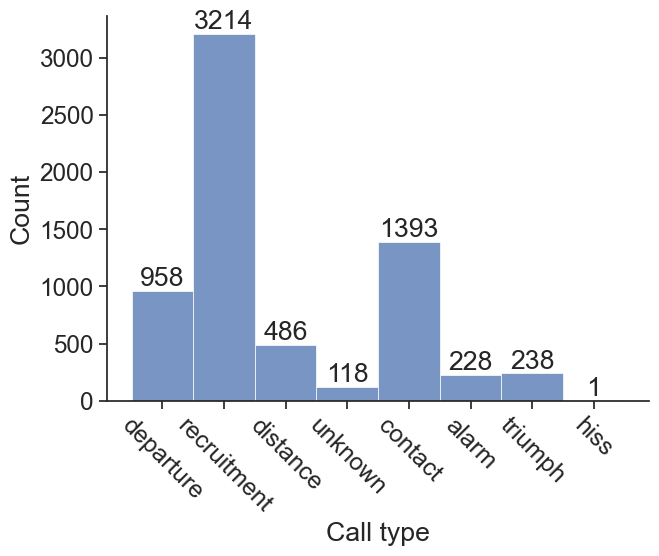

In [285]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

hist = sns.histplot(
    calls_df,
    x="Call Type",
    multiple="stack",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
)

plt.xticks(rotation=-45)
ax.set_xlabel("Call type")

# Add counts
for p in hist.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    ax.annotate(f'{int(height)}', (x, height), ha='center', va='bottom')
    
plt.plot()

In [286]:
subset_df = resample_subset(200, calls_df)

In [287]:
lfccs_scaled, lfccs_df = create_representations_subdf_and_scale(subset_df, "log_padded_lfccs")
mfccs_scaled, mfccs_df = create_representations_subdf_and_scale(subset_df, "log_padded_mfccs")
spectrograms_scaled, spectrograms_df = create_representations_subdf_and_scale(subset_df, "log_padded_spectrogram")
paf_scaled = StandardScaler().fit_transform(subset_df.drop(columns=[col for col in subset_df.columns if col not in audio_feature_columns]))        
_, vae_df = create_representations_subdf_and_scale(subset_df, "latent_representation")

In [288]:
print(lfccs_scaled.max(), lfccs_scaled.min())
print(mfccs_scaled.max(), mfccs_scaled.min())
print(spectrograms_scaled.max(), spectrograms_scaled.min())
print(paf_scaled.max(), paf_scaled.min())

22.903713421614576 -9.37195775659246
21.06328031429877 -6.86007765858783
32.911118 -1.3081218
9.642831765684416 -4.628508649373737


In [289]:
nn_results_paf = nearest_neighbors(paf_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
nn_results_lfcc = nearest_neighbors(lfccs_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
nn_results_mfcc = nearest_neighbors(mfccs_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
nn_results_spec = nearest_neighbors(spectrograms_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
nn_results_vae = nearest_neighbors(vae_df.drop(columns=["Call Type", "Track ID", "Goose ID"]), n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)

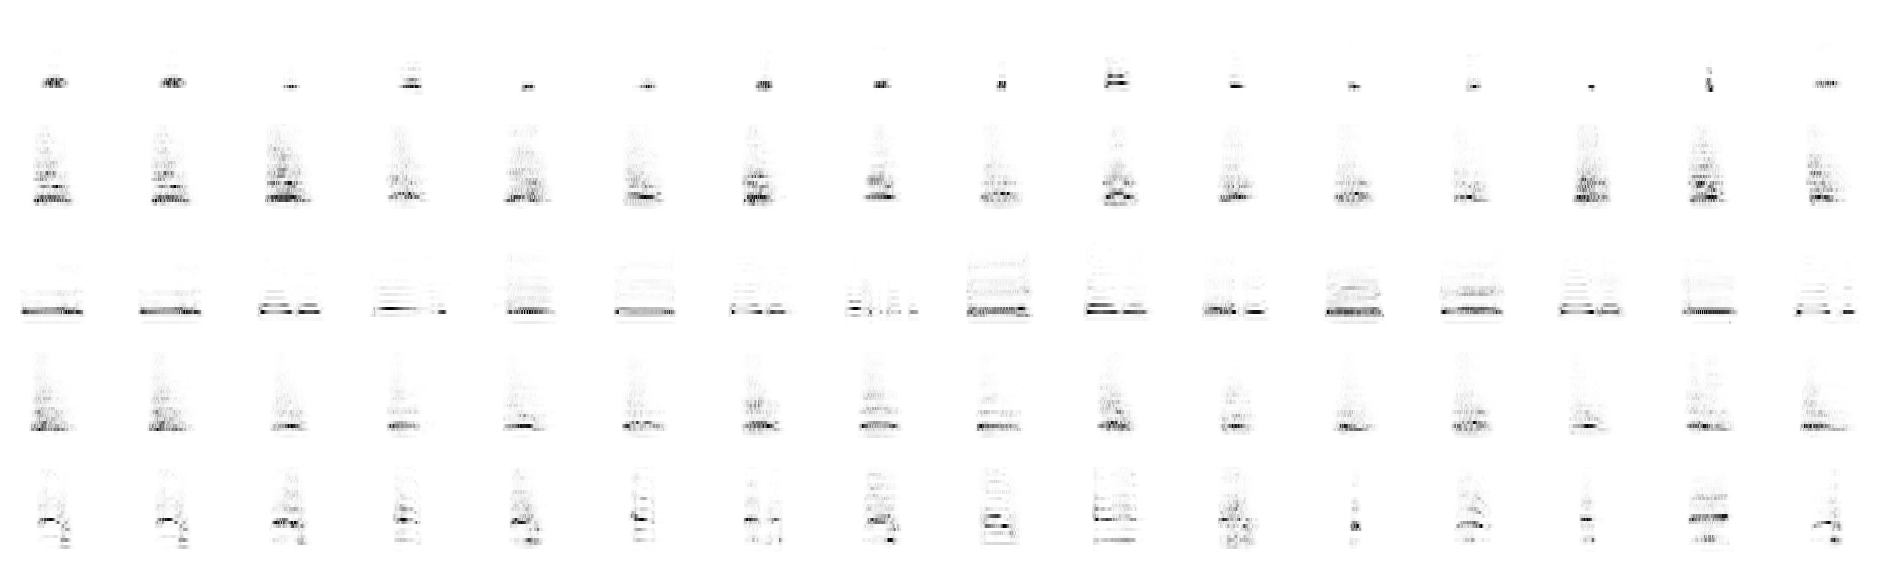

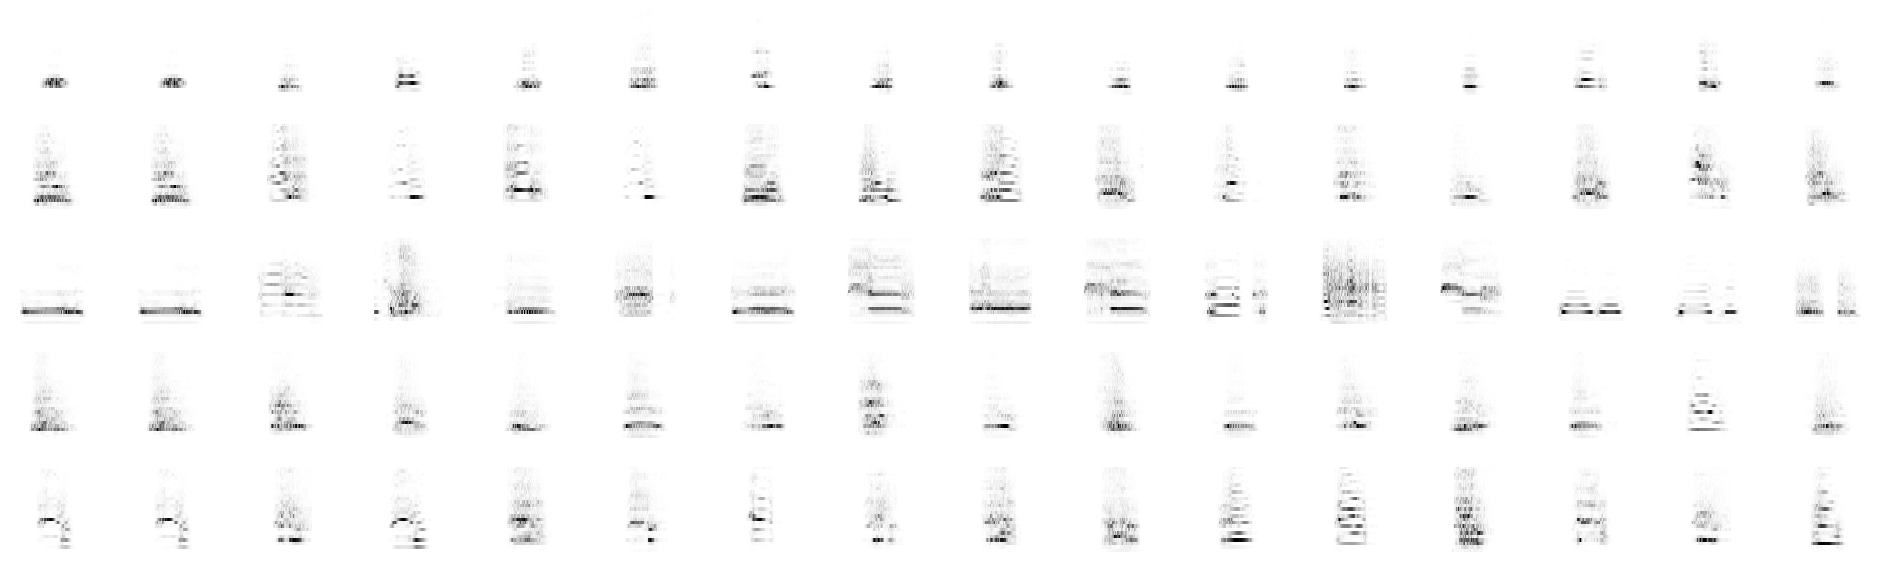

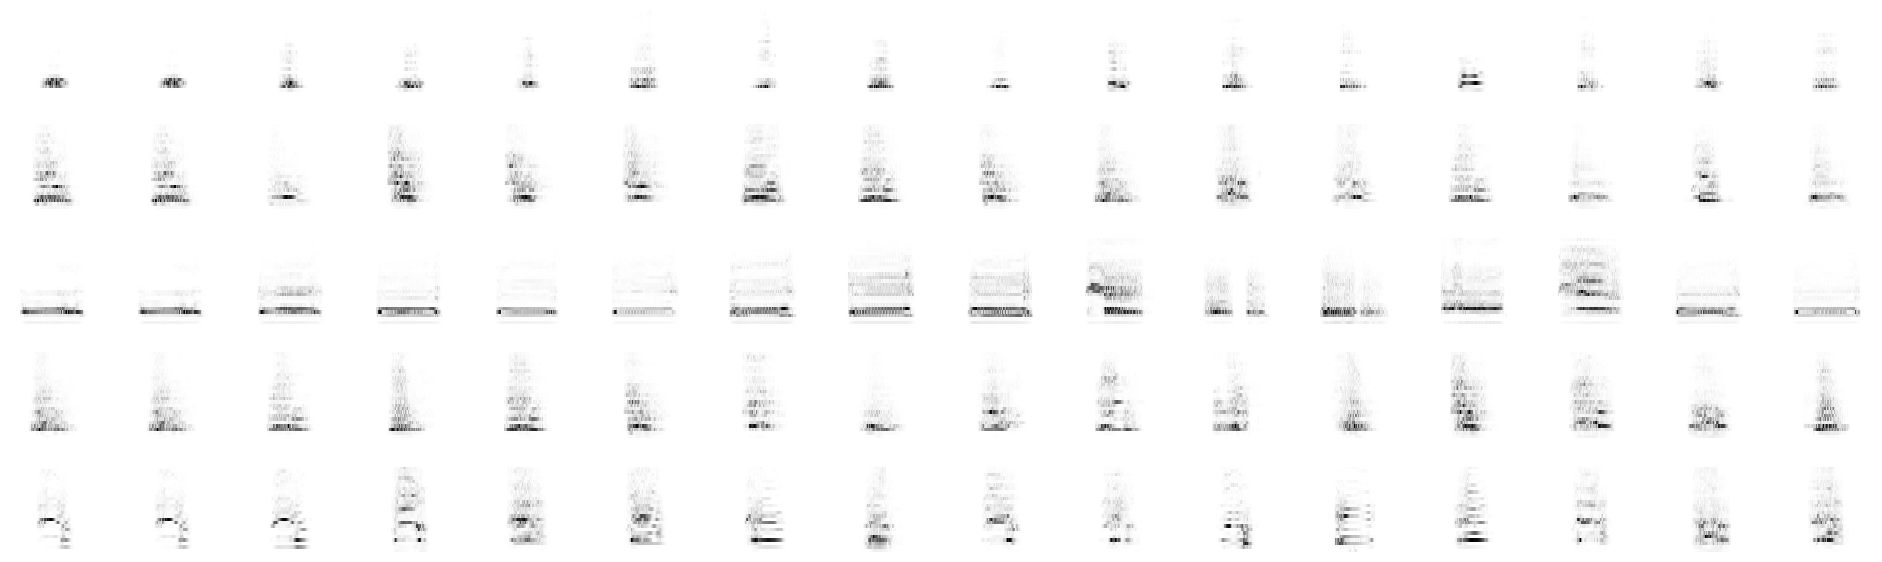

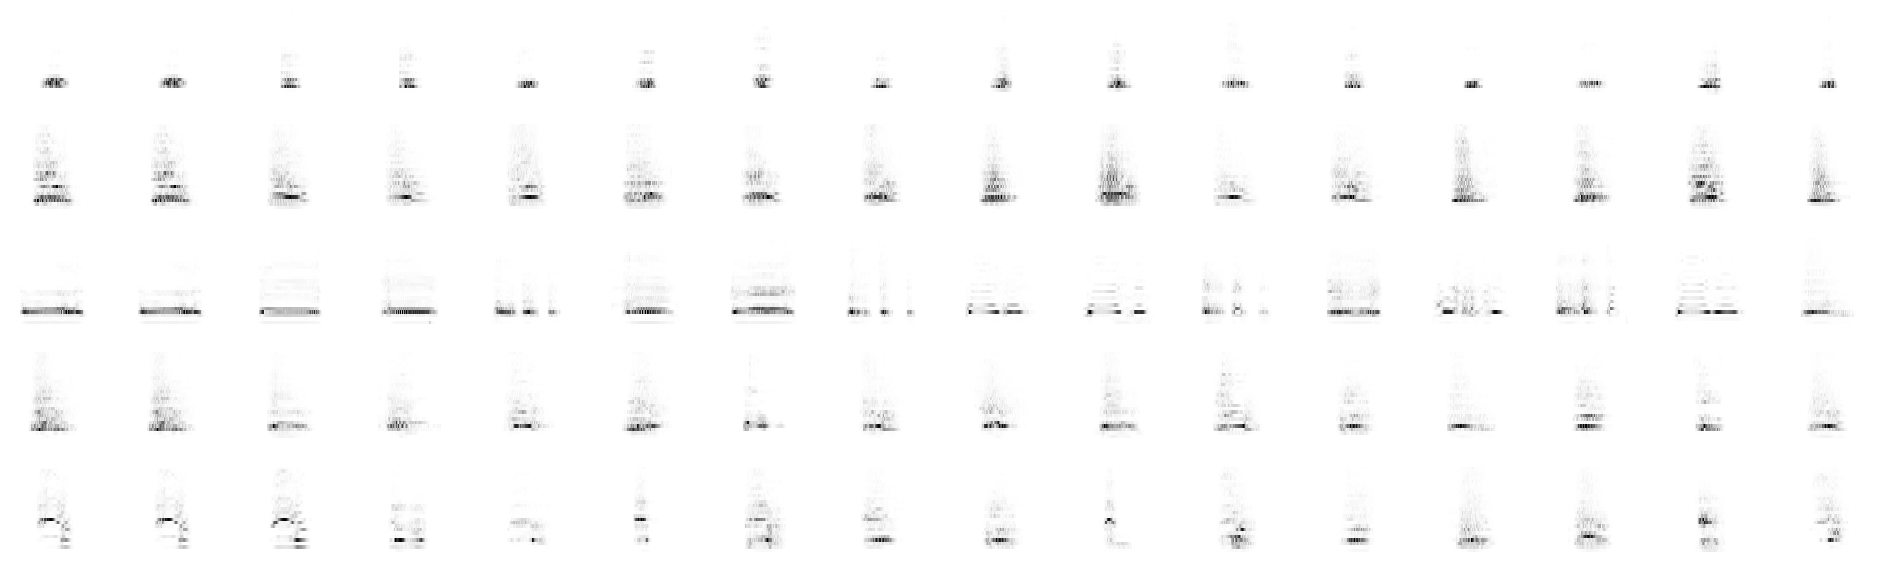

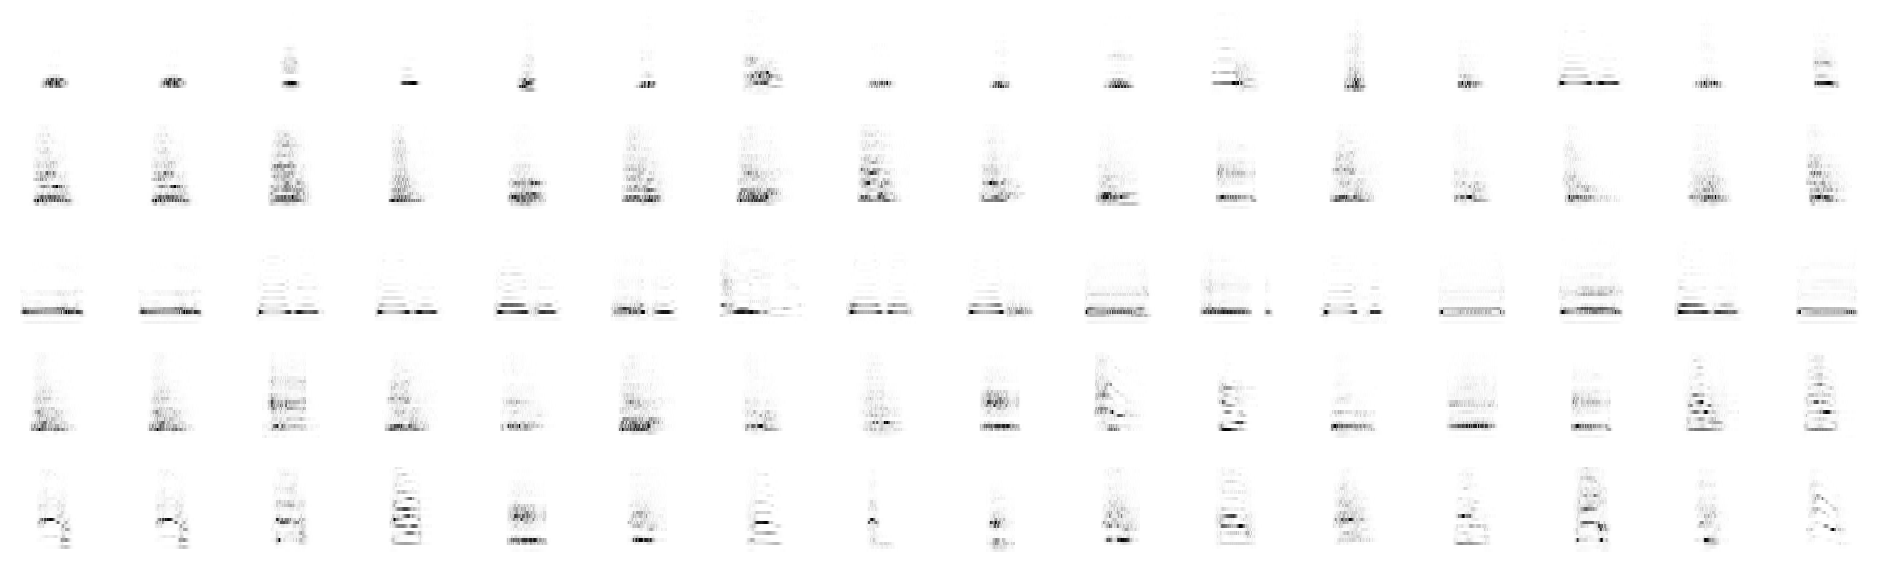

In [290]:
display_nearest_neighbours(nn_results_paf, subset_df, seed=42)
display_nearest_neighbours(nn_results_lfcc, subset_df, seed=42)
display_nearest_neighbours(nn_results_mfcc, subset_df, seed=42)
display_nearest_neighbours(nn_results_spec, subset_df, seed=42)
display_nearest_neighbours(nn_results_vae, subset_df, seed=42)

In [291]:
embeddings_paf = umap.UMAP(precomputed_knn=nn_results_paf, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(paf_scaled)
embeddings_lfcc = umap.UMAP(precomputed_knn=nn_results_lfcc, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(lfccs_scaled)
embeddings_mfcc = umap.UMAP(precomputed_knn=nn_results_mfcc, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(mfccs_scaled)
embeddings_spec = umap.UMAP(precomputed_knn=nn_results_spec, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(spectrograms_scaled)
embeddings_vae = umap.UMAP(precomputed_knn=nn_results_vae, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(vae_df.drop(columns=["Call Type", "Track ID", "Goose ID"]))
        

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


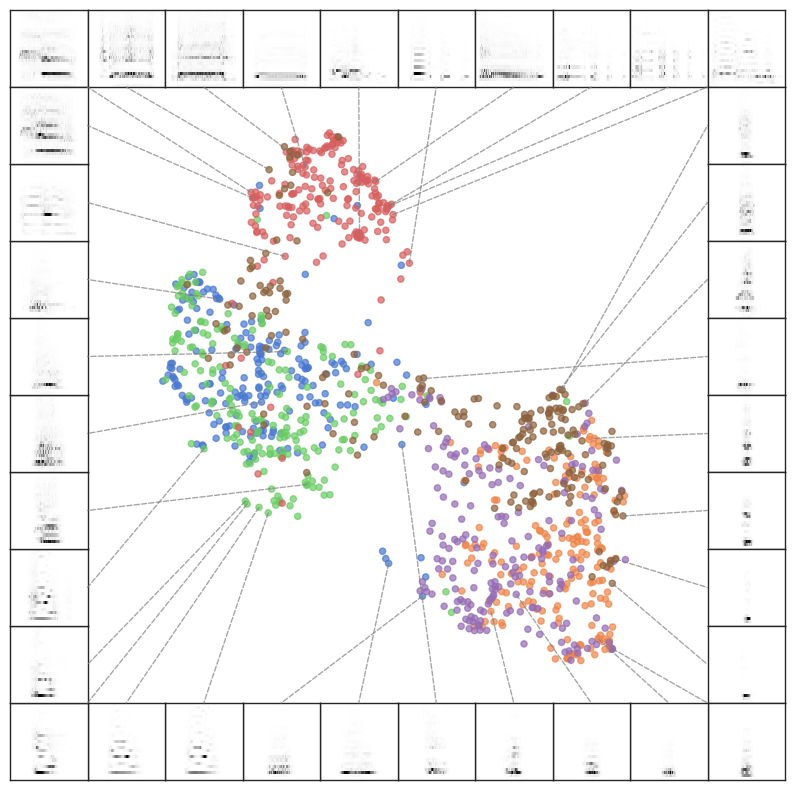

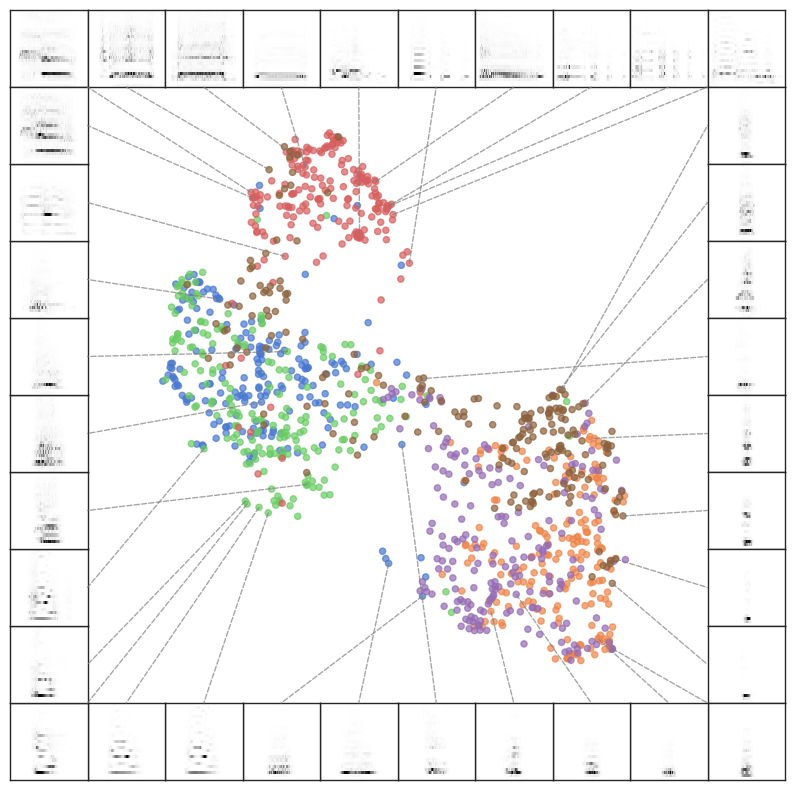

In [292]:
scatter_spec(
    embeddings_spec, 
    subset_df["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.7, "s": 20, "labels": subset_df["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

In [293]:
columns = [
    'Representation', 
    'Algorithm', 
    'Distance metric', 
    'Subset size', 
    'Cluster labels', 
    'V-measure', 
    'Adj. RS', 
    'Hopkins', 
    'Silhouette Score', 
    'Modularity',
    'Homogeneity',
    'Completeness'
    ]

results_df = pd.DataFrame(columns=columns)

In [294]:
from joblib import Parallel, delayed
import warnings

NEIGHBORS_RATIO = 0.2
algorithms = [  
            ("k-means", 0), 
            ("HDBSCAN", 1),
            ("Leiden", 2), 
        ]
rows = []

def run_subset(n_dimensions, subset_size, RANDOM_SEED=42):
    warnings.filterwarnings('ignore')
    vis_data = {}
    rows = []

    # n_classes = 6 if 200 <= subset_size <= 4000 else 5
    subset_df = calls_df.copy() if subset_size <= 100 or 4000 else calls_df[~calls_df["Call Type"].isin(["alarm", "triumph"])].copy()

    # resample dataset
    iterations = 20 if subset_size<4000 else 5
    for i in range(iterations) if subset_size<4000 else range(iterations):
        print(f"run {i+1}/{iterations}, dimensions: {n_dimensions}, subset size: {subset_size}")
        RANDOM_SEED+=100

        # n_neighbors
        if int(subset_size * NEIGHBORS_RATIO) >= 15:
            n_neighbors = int(subset_size * NEIGHBORS_RATIO)
        elif subset_size < 4000:
            n_neighbors = 100
        else:
            n_neighbors = 15 # for subset size 50

        subset_df = resample_subset(subset_size, subset_df)

        # Encode call type
        le = LabelEncoder()
        le.fit(subset_df["Call Type"])
        subset_df["encoded_call_type"] = le.transform(subset_df["Call Type"])

        # Load representation dataframes
        paf_scaled = StandardScaler().fit_transform(subset_df.drop(columns=[col for col in calls_df.columns if col not in audio_feature_columns]))
        lfccs_scaled, _ = create_representations_subdf_and_scale(subset_df, "log_padded_lfccs")
        mfccs_scaled, _ = create_representations_subdf_and_scale(subset_df, "log_padded_mfccs")
        spectrograms_scaled, _ = create_representations_subdf_and_scale(subset_df, "log_padded_spectrogram")
        _, vae_df = create_representations_subdf_and_scale(subset_df, "latent_representation")

        # NN Graphs
        nn_results_paf = nearest_neighbors(paf_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False, n_jobs=1)
        nn_results_lfcc = nearest_neighbors(lfccs_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False, n_jobs=1)
        nn_results_mfcc = nearest_neighbors(mfccs_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False, n_jobs=1)
        nn_results_spec = nearest_neighbors(spectrograms_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False, n_jobs=1)
        nn_results_vae = nearest_neighbors(vae_df.drop(columns=["Call Type", "Track ID", "Goose ID"]), n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False, n_jobs=1)
        
        # Reduce dimensionality
        if n_dimensions<paf_scaled.shape[1]:
            embeddings_paf = umap.UMAP(precomputed_knn=nn_results_paf, n_neighbors=n_neighbors, n_components=n_dimensions, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(paf_scaled)
        else:
            #embeddings_paf = paf_scaled
            embeddings_paf = umap.UMAP(precomputed_knn=nn_results_paf, n_neighbors=n_neighbors, n_components=23, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(paf_scaled)
        embeddings_lfcc = umap.UMAP(precomputed_knn=nn_results_lfcc, n_neighbors=n_neighbors, n_components=n_dimensions, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(lfccs_scaled)
        embeddings_mfcc = umap.UMAP(precomputed_knn=nn_results_mfcc, n_neighbors=n_neighbors, n_components=n_dimensions, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(mfccs_scaled)
        embeddings_spec = umap.UMAP(precomputed_knn=nn_results_spec, n_neighbors=n_neighbors, n_components=n_dimensions, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(spectrograms_scaled)
        embeddings_vae = umap.UMAP(precomputed_knn=nn_results_vae, n_neighbors=n_neighbors, n_components=n_dimensions, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(vae_df.drop(columns=["Call Type", "Track ID", "Goose ID"]))
        if subset_size == 100 and i==iterations-1 and n_dimensions ==2:
            vis_data = {
                "subset_df": subset_df,
                "embeddings": {
                    "paf": embeddings_paf,
                    "lfcc": embeddings_lfcc,
                    "mfcc": embeddings_mfcc,
                    "spec": embeddings_spec,
                    "vae": embeddings_vae,
                }
            }
        # Cluster
        # kMeans
        _, _, labels_kMeans_paf = silhouette_analysis_kmeans(embeddings_paf, plot_best_clustering=False)
        _, _, labels_kMeans_lfcc = silhouette_analysis_kmeans(embeddings_lfcc, plot_best_clustering=False)
        _, _, labels_kMeans_mfcc = silhouette_analysis_kmeans(embeddings_mfcc, plot_best_clustering=False)
        _, _, labels_kMeans_spec = silhouette_analysis_kmeans(embeddings_spec, plot_best_clustering=False)
        _, _, labels_kMeans_vae = silhouette_analysis_kmeans(embeddings_vae, plot_best_clustering=False)

        # HDBSCAN
        _, _, labels_HDBSCAN_paf = silhouette_analysis_hdbscan(embeddings_paf, plot_best_clustering=False)
        _, _, labels_HDBSCAN_lfcc = silhouette_analysis_hdbscan(embeddings_lfcc, plot_best_clustering=False)
        _, _, labels_HDBSCAN_mfcc = silhouette_analysis_hdbscan(embeddings_mfcc, plot_best_clustering=False)
        _, _, labels_HDBSCAN_spec = silhouette_analysis_hdbscan(embeddings_spec, plot_best_clustering=False)
        _, _, labels_HDBSCAN_vae = silhouette_analysis_hdbscan(embeddings_vae, plot_best_clustering=False)

        # Leiden
        labels_Leiden_paf, partition_paf, ig_graph_paf = leiden_cluster_from_nn_graph(nn_results_paf)
        labels_Leiden_lfcc, partition_lfcc, ig_graph_lfcc = leiden_cluster_from_nn_graph(nn_results_lfcc)
        labels_Leiden_mfcc, partition_mfcc, ig_graph_mfcc = leiden_cluster_from_nn_graph(nn_results_mfcc)
        labels_Leiden_spec, partition_spec, ig_graph_spec = leiden_cluster_from_nn_graph(nn_results_spec)
        labels_Leiden_vae, partition_vae, ig_graph_vae = leiden_cluster_from_nn_graph(nn_results_vae)
        
        # Append to results DataFrame
        representations = [
            ("Audio Features", embeddings_paf, partition_paf, labels_kMeans_paf, labels_HDBSCAN_paf, labels_Leiden_paf, ig_graph_paf),
            ("LFCC", embeddings_lfcc, partition_lfcc, labels_kMeans_lfcc, labels_HDBSCAN_lfcc, labels_Leiden_lfcc, ig_graph_lfcc),
            ("MFCC", embeddings_mfcc, partition_mfcc, labels_kMeans_mfcc, labels_HDBSCAN_mfcc, labels_Leiden_mfcc, ig_graph_mfcc),
            ("Spectrogram", embeddings_spec, partition_spec, labels_kMeans_spec, labels_HDBSCAN_spec, labels_Leiden_spec, ig_graph_spec),
            ("VAE", embeddings_vae, partition_vae, labels_kMeans_vae, labels_HDBSCAN_vae, labels_Leiden_vae, ig_graph_vae),
        ]

        for rep_name, embeddings, partition, labels_kMeans, labels_HDBSCAN, labels_Leiden, graph in representations:
            for algorithm_name, label_index in algorithms:
                labels = [labels_kMeans, labels_HDBSCAN, labels_Leiden][label_index]

                new_row = {
                    "Dimensionality": n_dimensions,
                    "Representation": rep_name,
                    "Algorithm": algorithm_name,
                    "Distance metric": DISTANCE_METRIC,
                    "Subset size": subset_size,
                    "N clusters": np.max(labels)+1 if labels is not None else None,
                    "V-measure": v_measure_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Adj. RS": adjusted_rand_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Hopkins": hopkins(embeddings, RANDOM_SEED),
                    "Silhouette Score": silhouette_score(embeddings, labels, sample_size=500) if labels is not None else silhouette_on_graph(graph, partition.membership),
                    "Modularity": partition.modularity if algorithm_name is not None else None,
                    "Homogeneity": homogeneity_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Completeness": completeness_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                }
                rows.append(new_row)
    return rows, vis_data

results = Parallel(n_jobs=-1)(
    delayed(run_subset)(n_dimensions, subset_size) 
    for n_dimensions in [2, 20, 100] 
    for subset_size in [50, 100, 200, 500, 4000]
)

rows = [row for sublist, _ in results for row in sublist]
vis_data = [vis for _, vis in results if vis]

new_df = pd.DataFrame(rows)
if results_df.empty:
    results_df = new_df
else:
    results_df = pd.concat([results_df, new_df], ignore_index=True)

run 1/20, dimensions: 2, subset size: 50
run 1/20, dimensions: 2, subset size: 100
run 1/20, dimensions: 2, subset size: 200
run 1/20, dimensions: 2, subset size: 500
run 1/5, dimensions: 2, subset size: 4000
run 1/20, dimensions: 20, subset size: 50
run 1/20, dimensions: 20, subset size: 100
run 1/20, dimensions: 20, subset size: 200
run 1/20, dimensions: 20, subset size: 500
run 1/5, dimensions: 20, subset size: 4000
run 1/20, dimensions: 100, subset size: 50
run 1/20, dimensions: 100, subset size: 100
run 1/20, dimensions: 100, subset size: 200
run 1/20, dimensions: 100, subset size: 500
run 1/5, dimensions: 100, subset size: 4000
run 2/20, dimensions: 2, subset size: 50
run 2/20, dimensions: 2, subset size: 100
run 2/20, dimensions: 20, subset size: 50
run 2/20, dimensions: 20, subset size: 100
run 3/20, dimensions: 2, subset size: 50
run 3/20, dimensions: 2, subset size: 100
run 2/20, dimensions: 100, subset size: 50
run 2/20, dimensions: 2, subset size: 200
run 3/20, dimensions: 

In [295]:
results_df.to_pickle(f"results_{str(
            datetime.datetime.today().strftime('%Y%m%d_%H%M%S')
            )}.pkl")

with open(f"embeddings_for_visualization_{str(
            datetime.datetime.today().strftime('%Y%m%d_%H%M%S')
            )}.pkl", "wb") as f:
    pickle.dump(vis_data, f)

# Load results and plot

In [313]:
with open(f"embeddings_for_visualization_20251001_123519.pkl", "rb") as f:
    vis_data = pickle.load(f)

results_df = pd.read_pickle("results_20251001_123519.pkl")

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/53669097.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/53669097.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/53669097.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/53669097.py:54: UserWarning: set_ticklabe

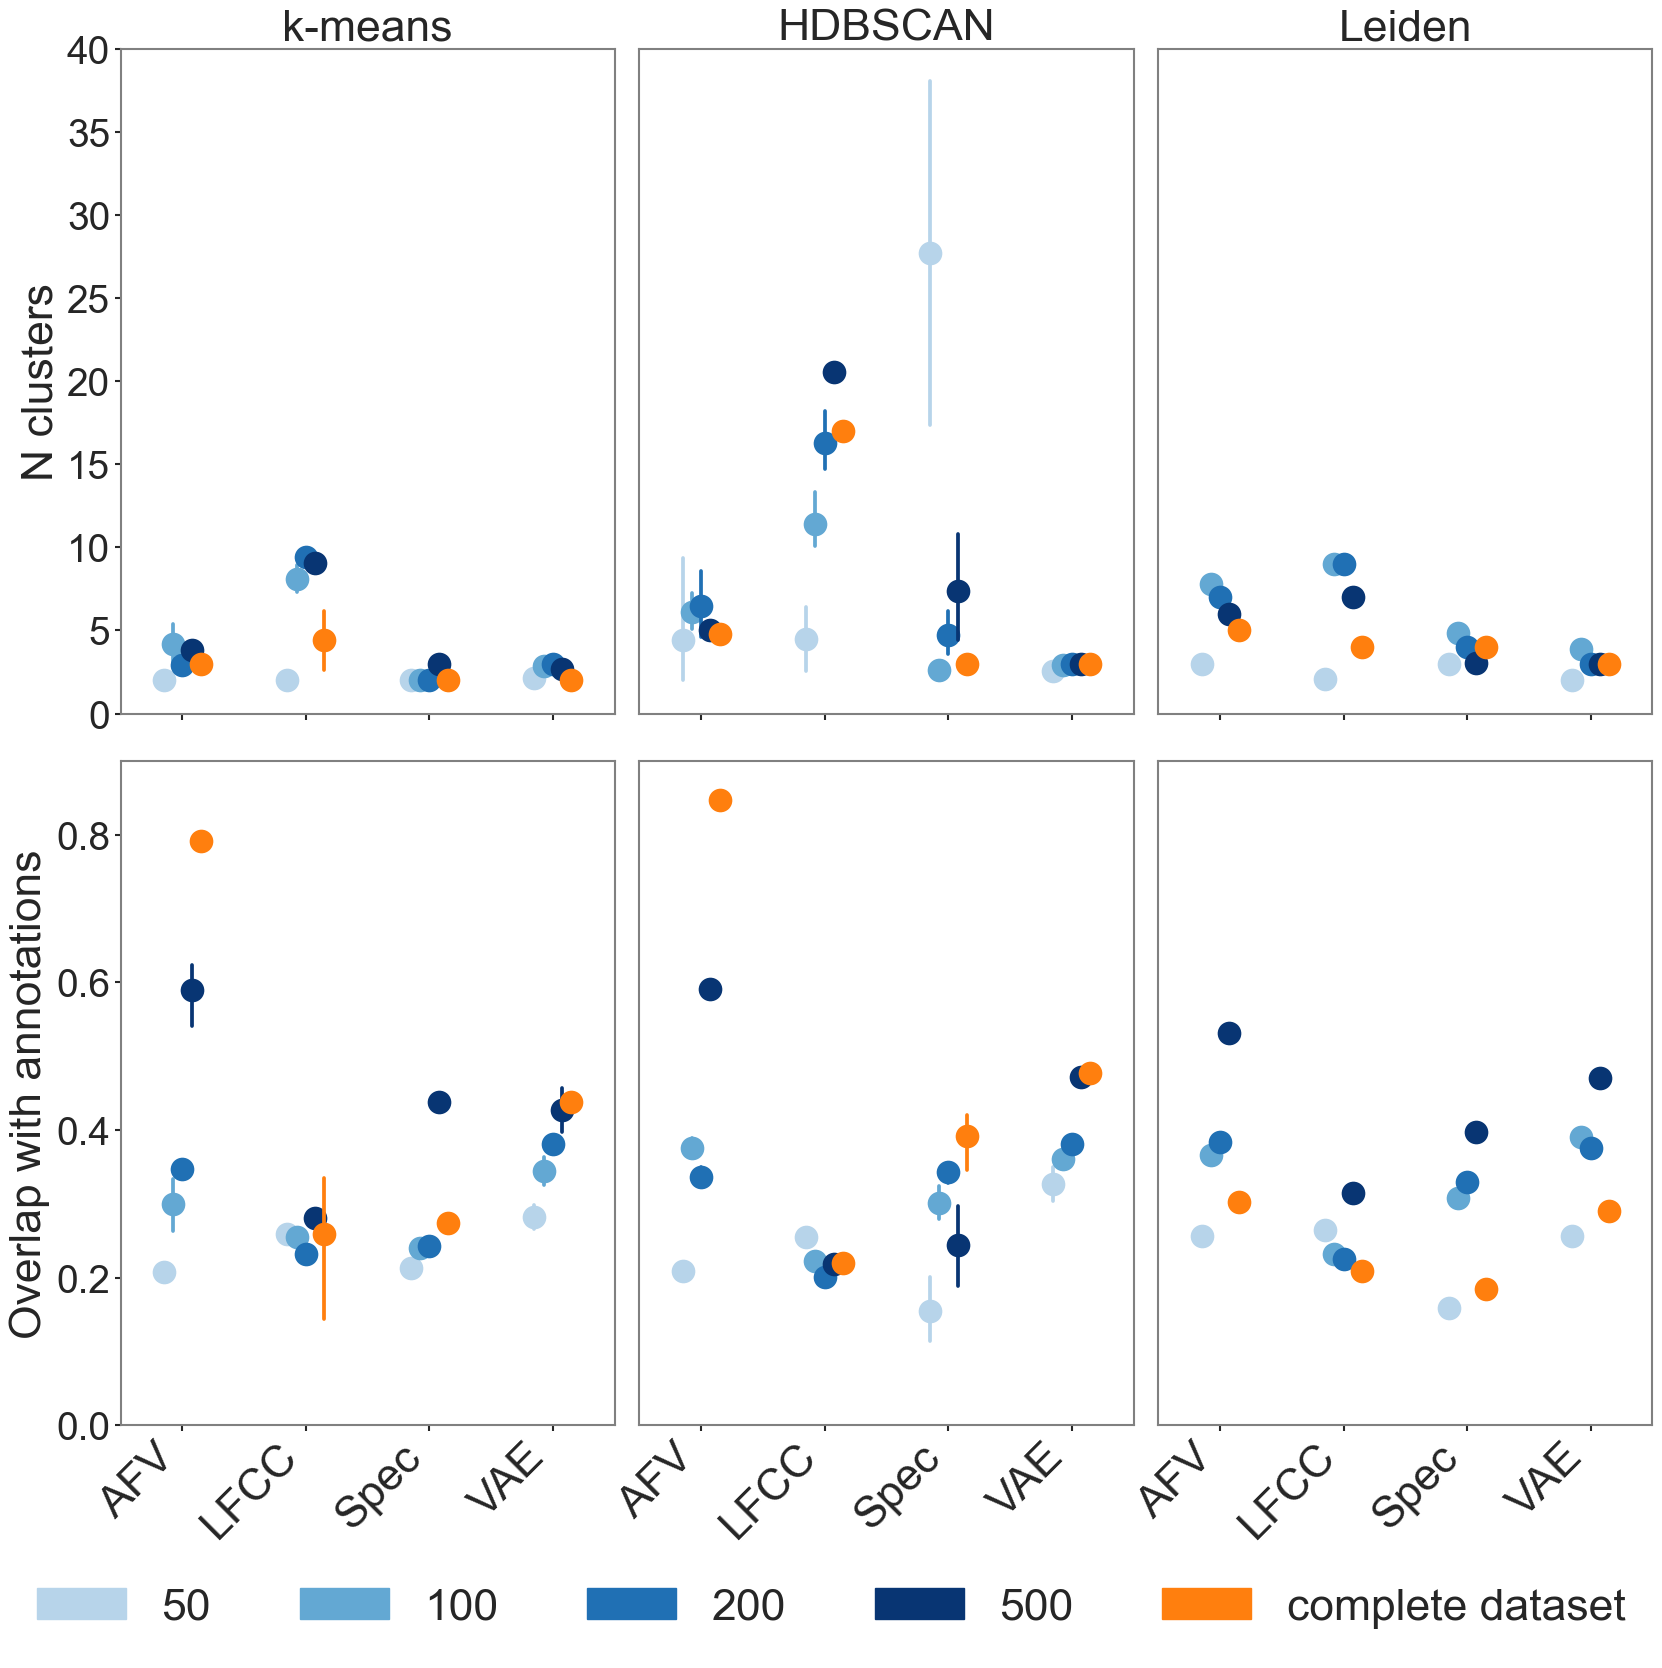

In [314]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 2) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 40)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2080746171.py:54: UserWarning: set_

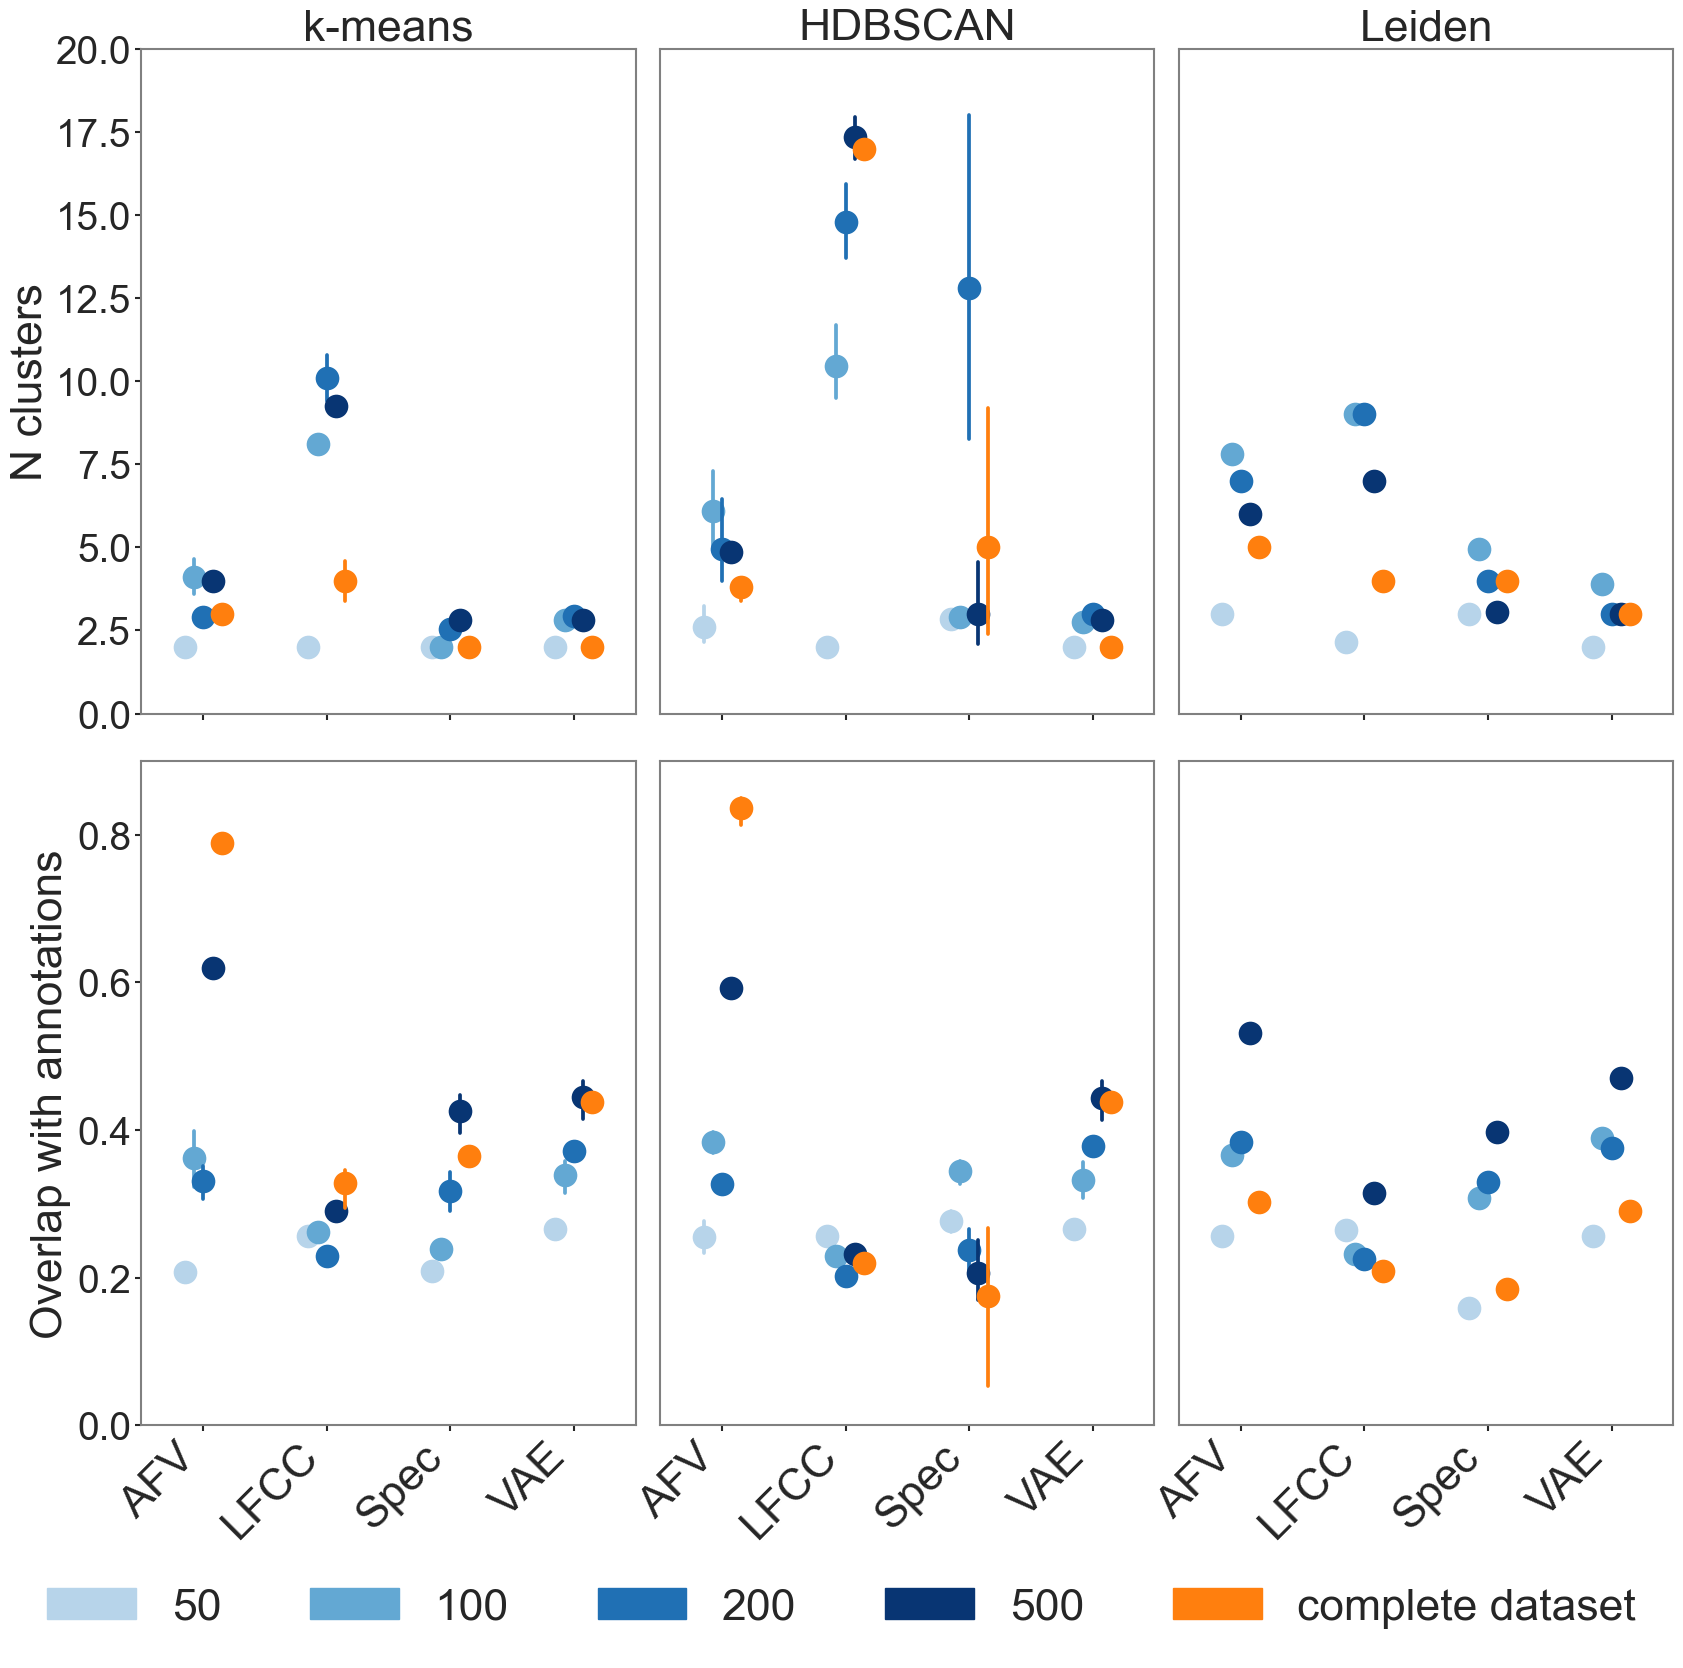

In [315]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 20) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/154244901.py:54: UserWarning: set_tick

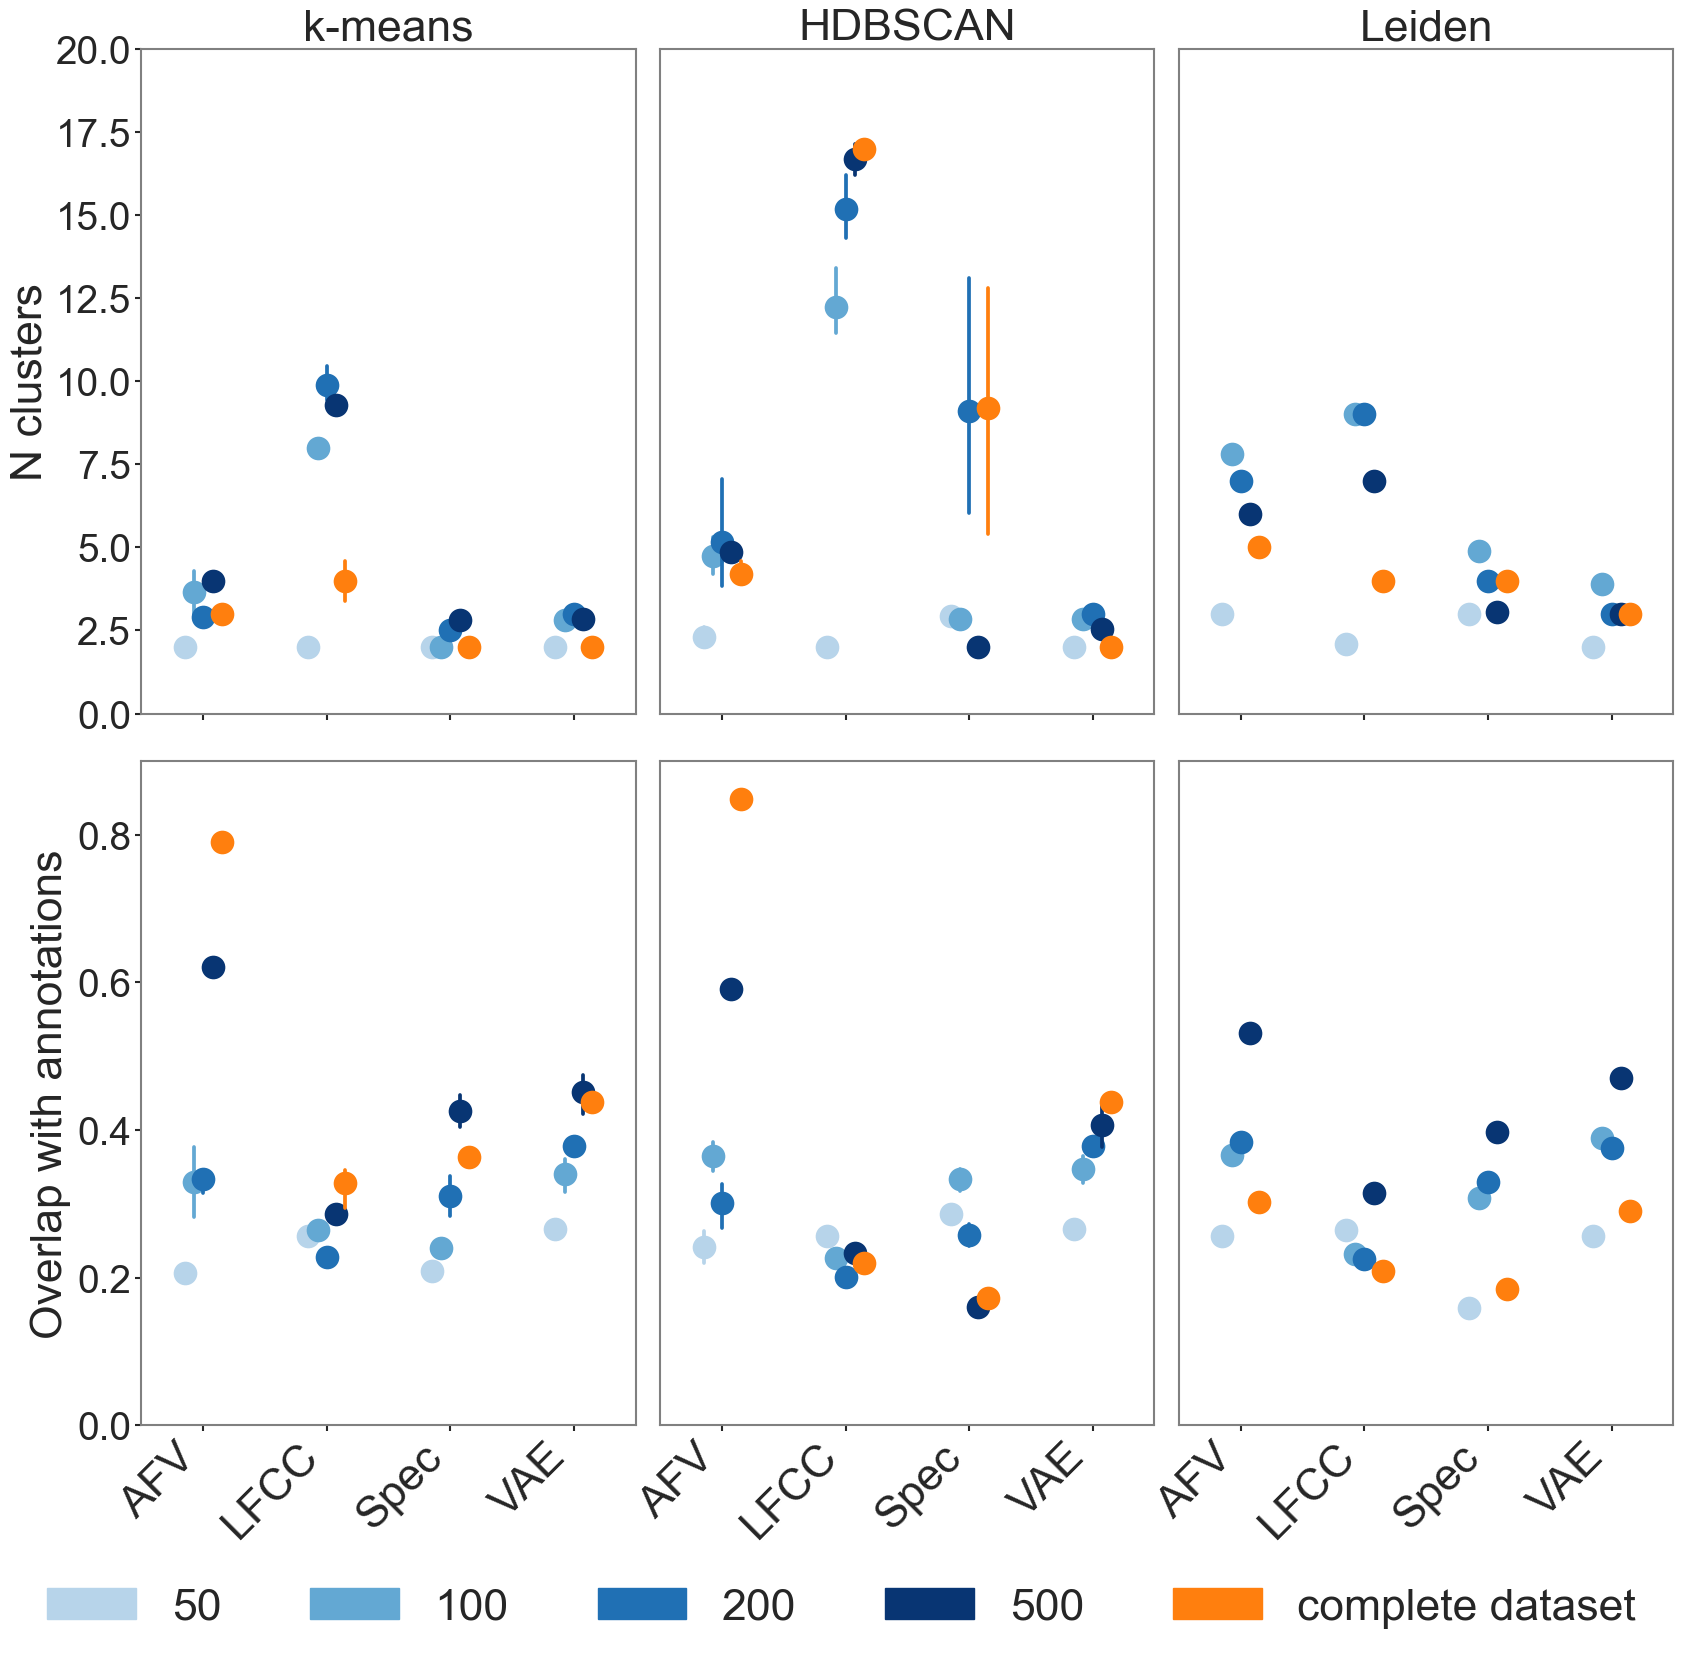

In [317]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 100) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/1841806617.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/1841806617.

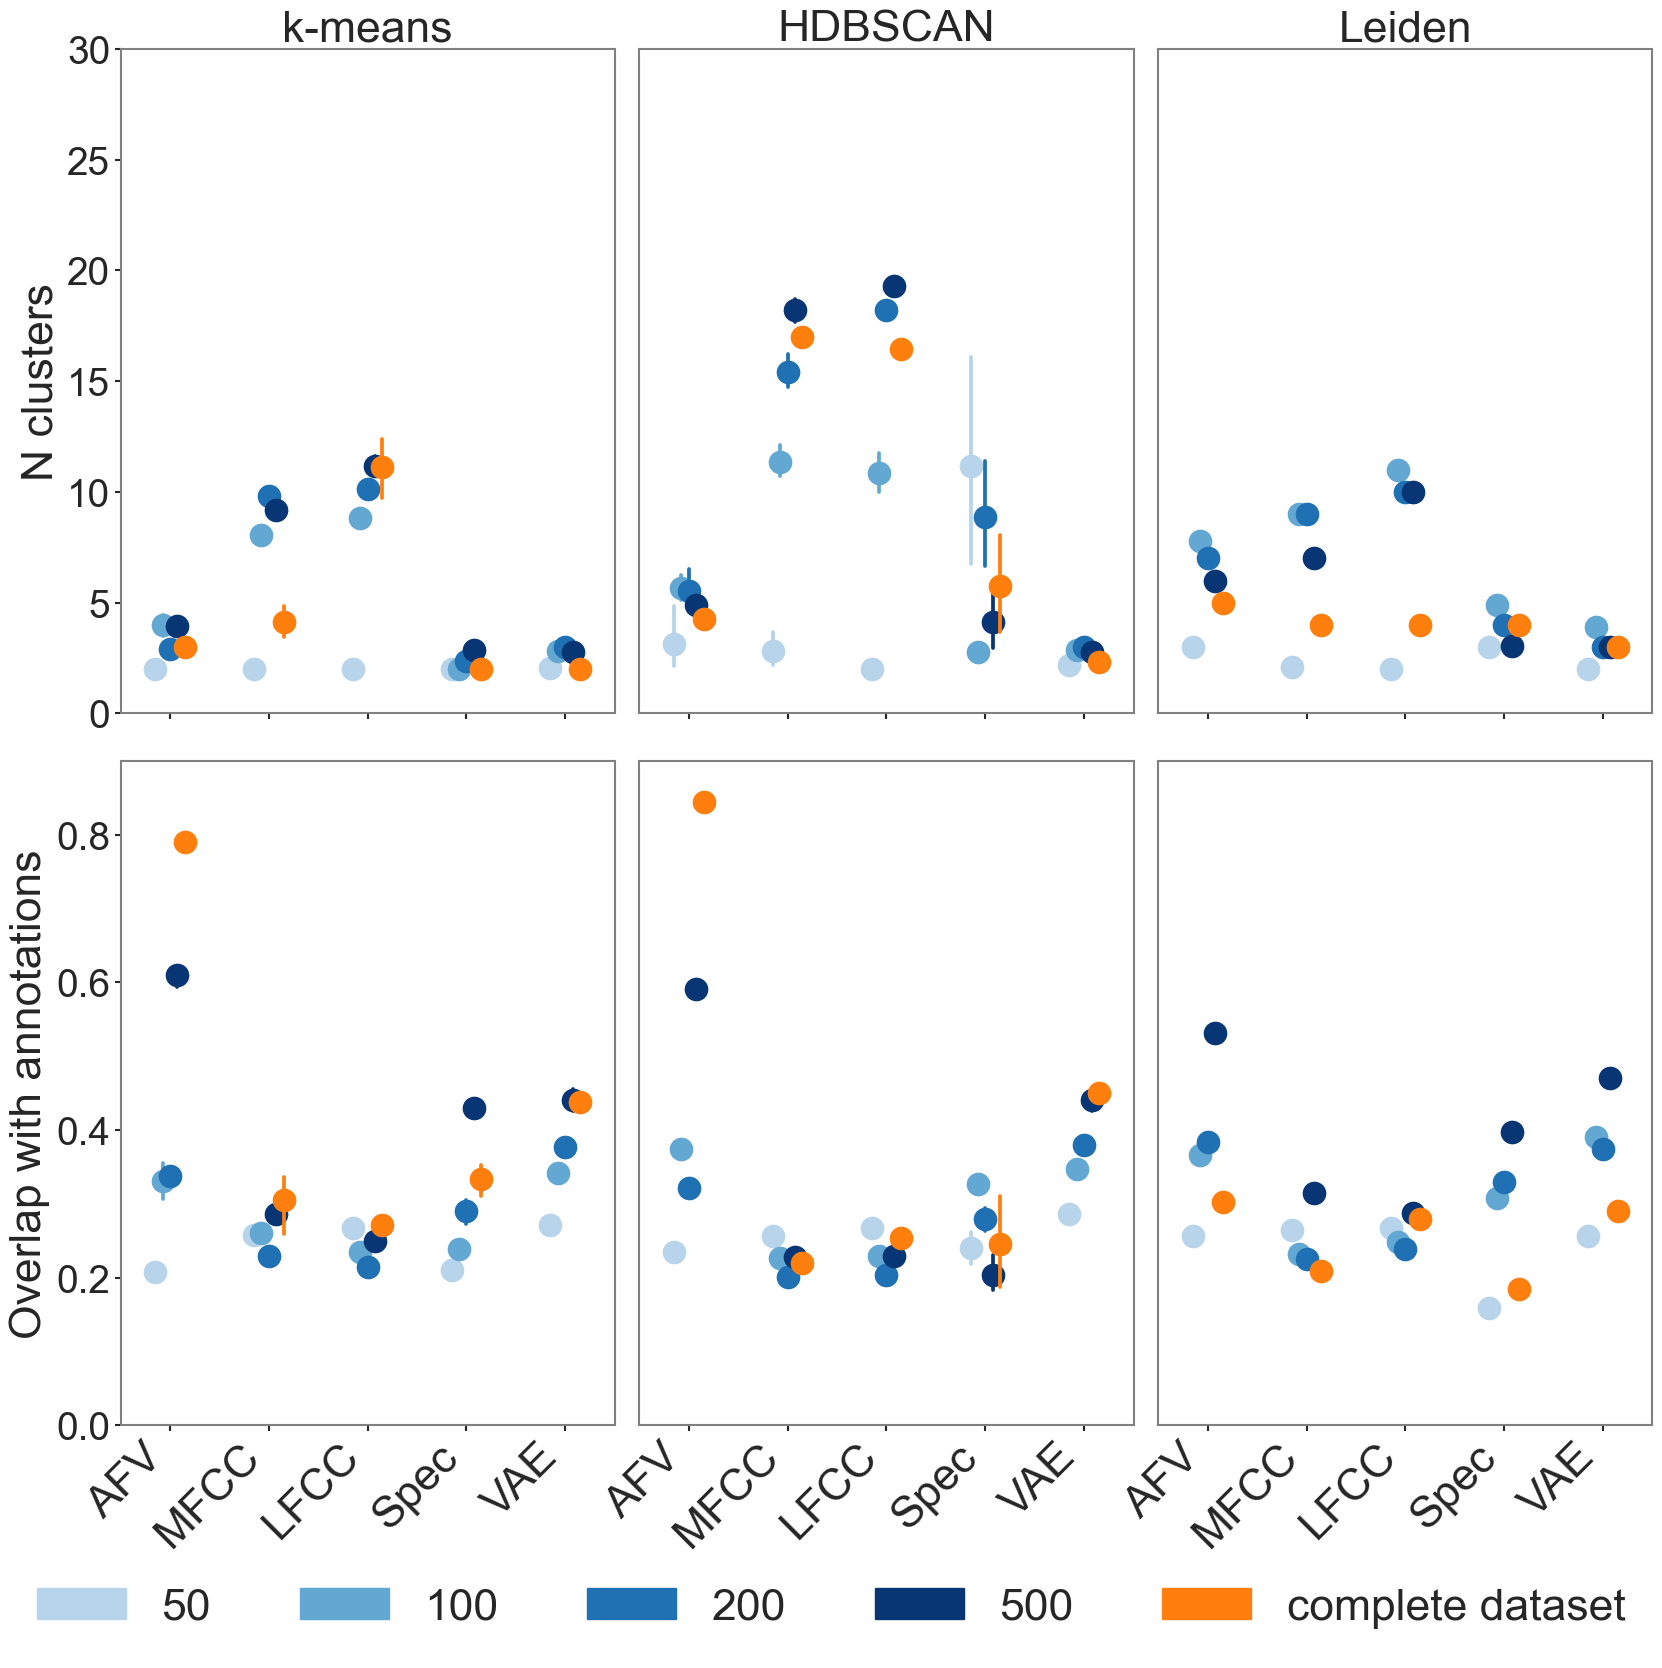

In [326]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "MFCC", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15,
            zorder=2
        )

        # sns.stripplot(
        #     x="Representation", 
        #     y=metric,  
        #     data=data, 
        #     ax=axs[row, col], 
        #     hue=hue_col,
        #     palette=palette,
        #     hue_order=hue_levels_metric,
        #     alpha=.15,
        #     dodge=.1,
        #     jitter=.7,
        #     legend=False,
        #     size=13,
        #     zorder=1
        # )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "MFCC", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 30)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2417974276.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_61467/2417974276.py:74: UserWarning: set_

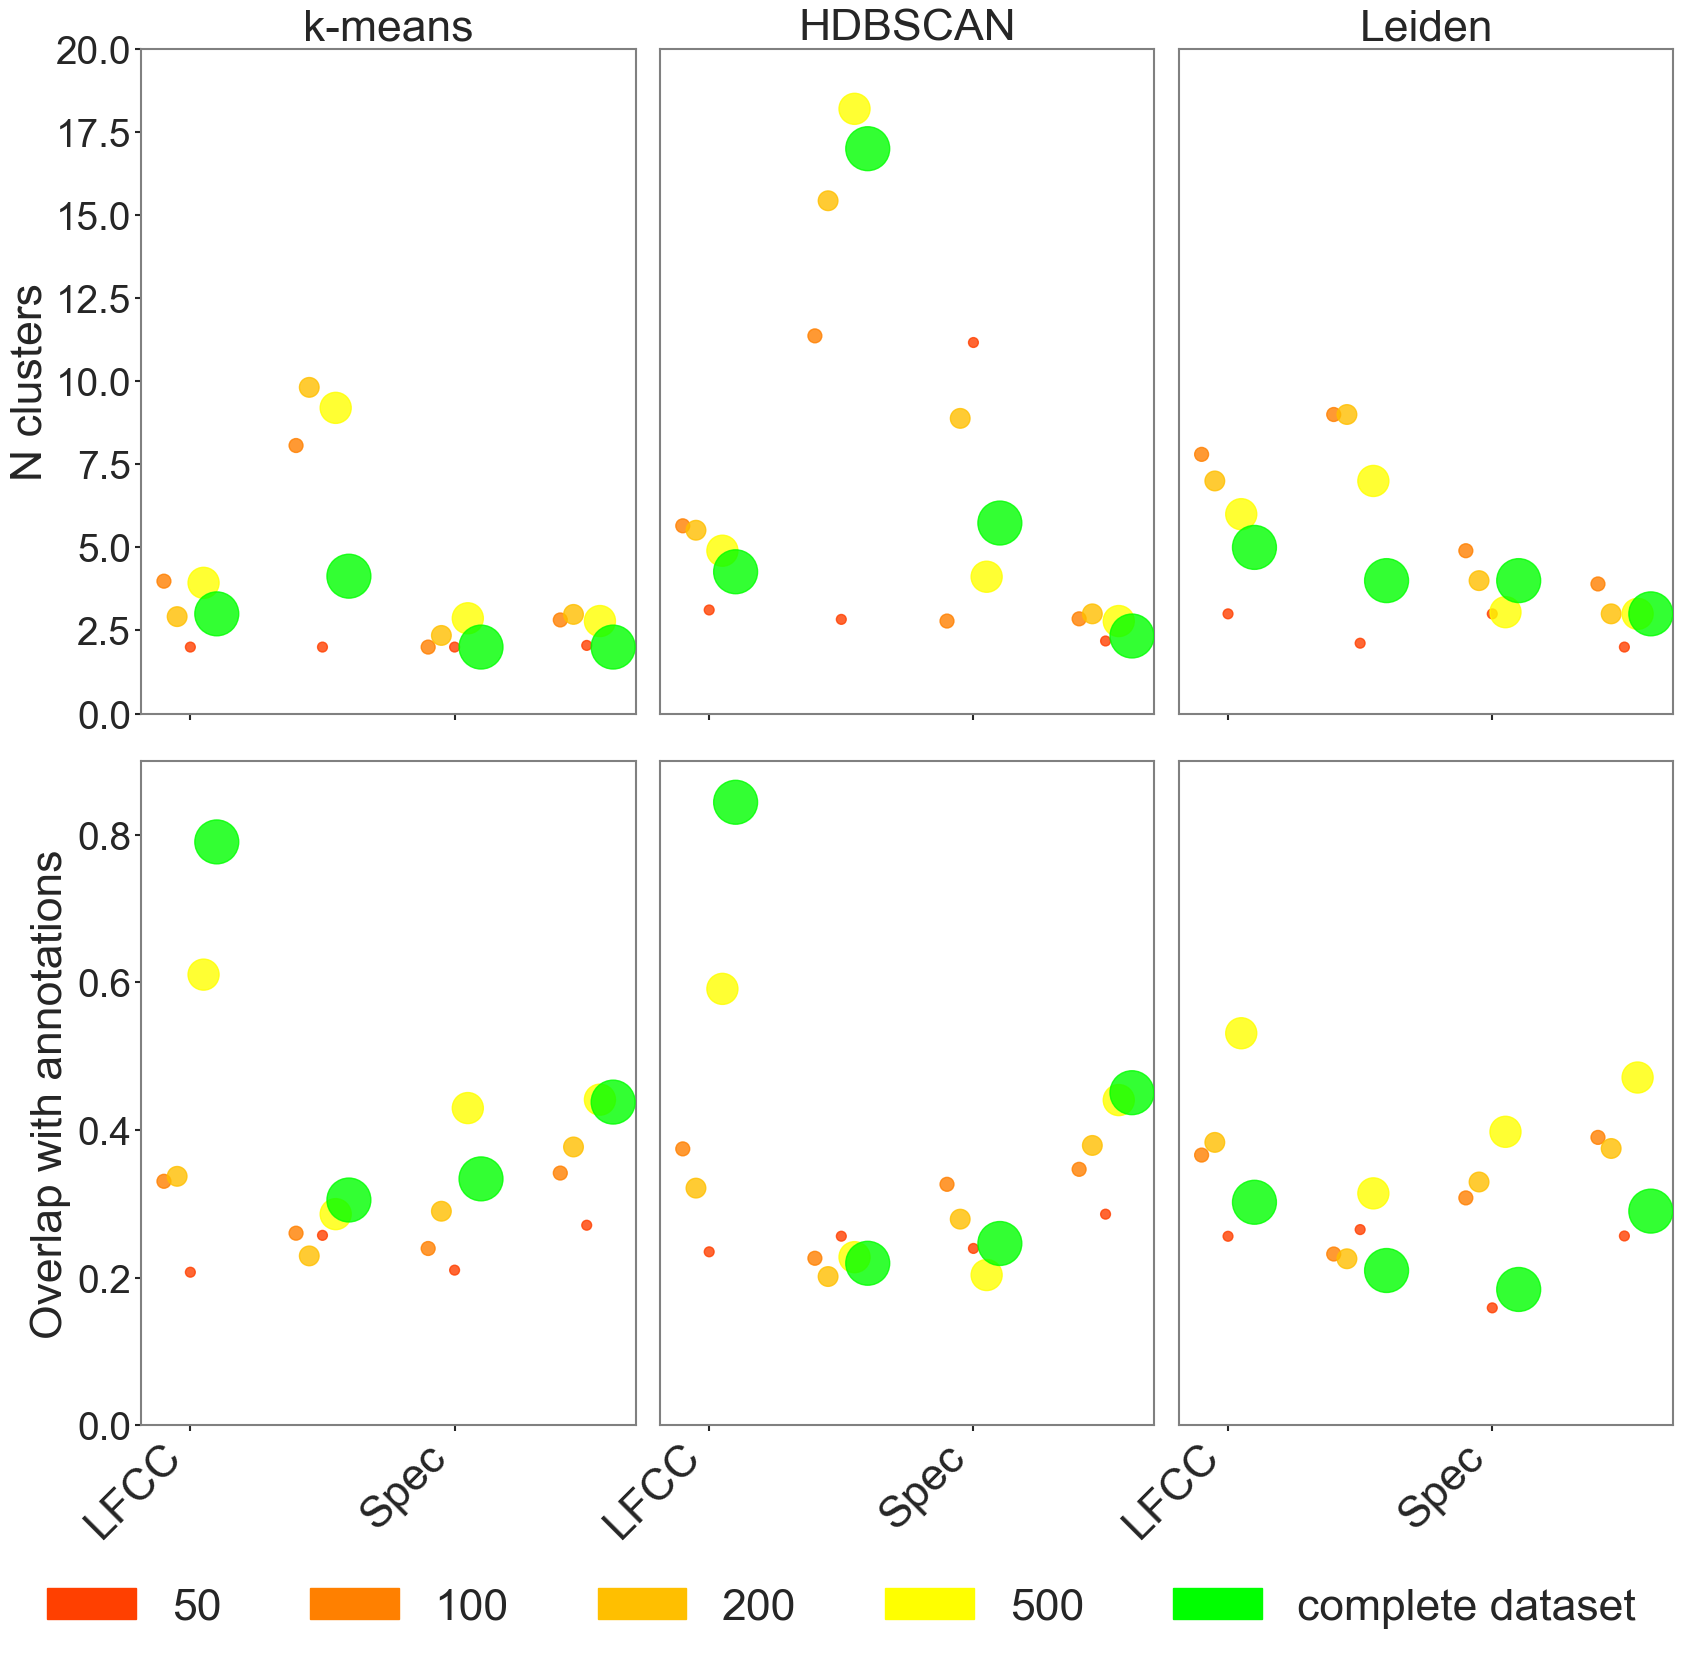

In [321]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  "#ff4000",   # darkest blue
            100: "#ff8000",
            200: "#ffbf00",
            500: "#ffff00",   # lightest blue
            "complete dataset": "#00ff00",  # tab20 orange
        }

        hue_col = "Subset size"
        size_mapping = {
            50:  50,  
            100: 100,
            200: 200,
            500: 500,  
            "complete dataset": 1000
        }

        means = pd.DataFrame(data.groupby(["Representation", "Subset size"])[metric].mean().reset_index())
        x_positions = {
            rep: i for i, rep in enumerate(means["Representation"].unique())
        }
        hue_levels = means["Subset size"].unique()
        n_hues = len(hue_levels)
        dodge_amount = 0.1

        offsets = {
            level: (i - (n_hues - 1) / 2) * dodge_amount
            for i, level in enumerate(sorted(hue_levels, key=lambda x: str(x)))
        }

        # scatter each subset size with an offset x
        for subset in hue_levels:
            sub_means = means[means["Subset size"] == subset]
            x_vals = [x_positions[r] + offsets[subset] for r in sub_means["Representation"]]
            y_vals = sub_means[metric].values

            axs[row, col].scatter(
                x_vals,
                y_vals,
                s=[size_mapping[subset]] * len(x_vals),
                color=palette[subset],
                label=subset,
                alpha=0.8,
                zorder=3,
            )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

In [322]:
vis_data_sub = vis_data[0]

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


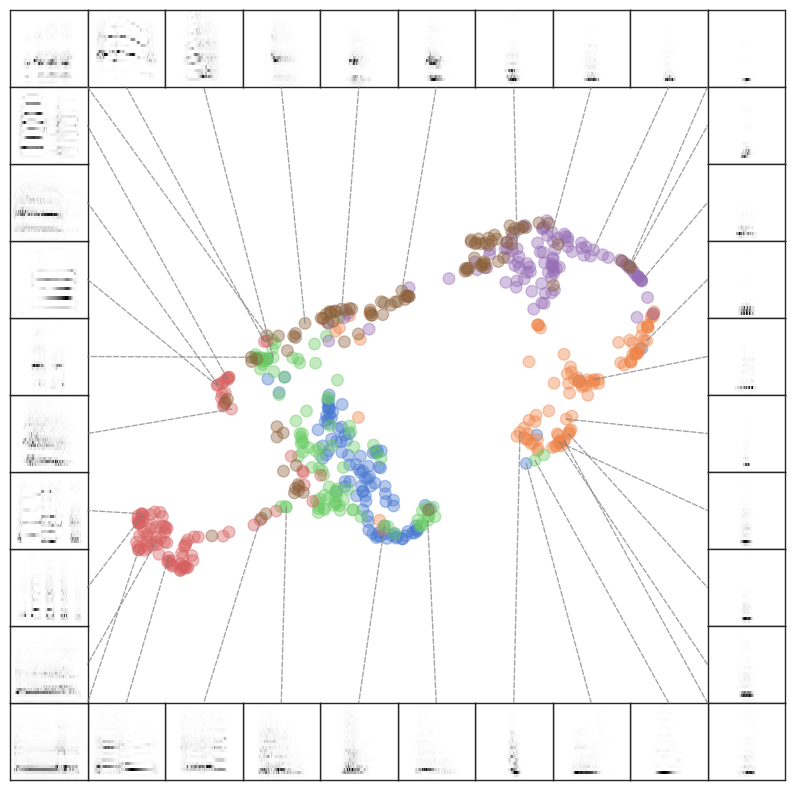

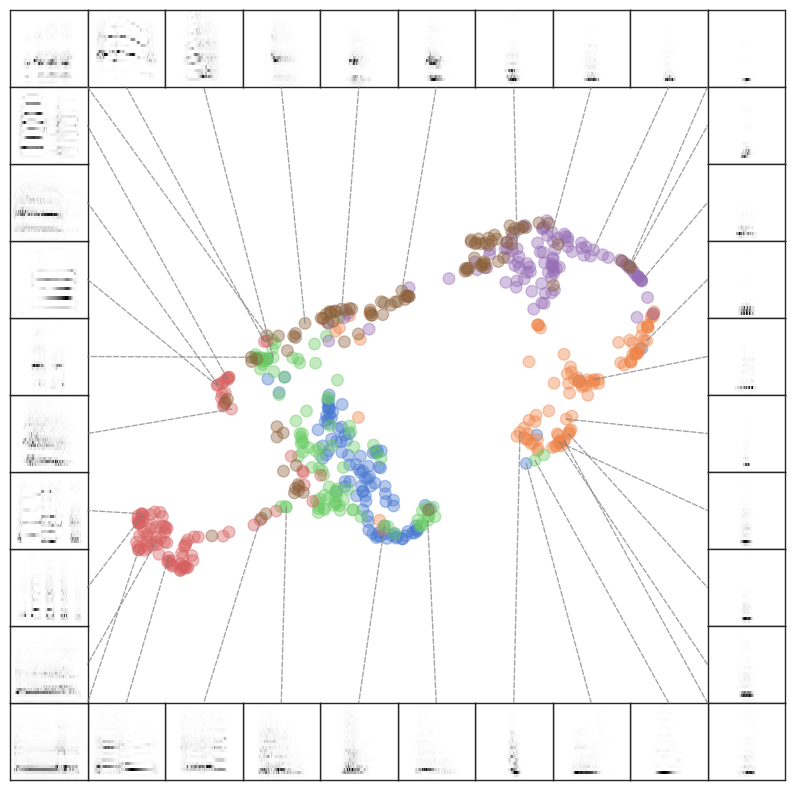

In [323]:
scatter_spec(
    vis_data_sub["embeddings"]["paf"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"],
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


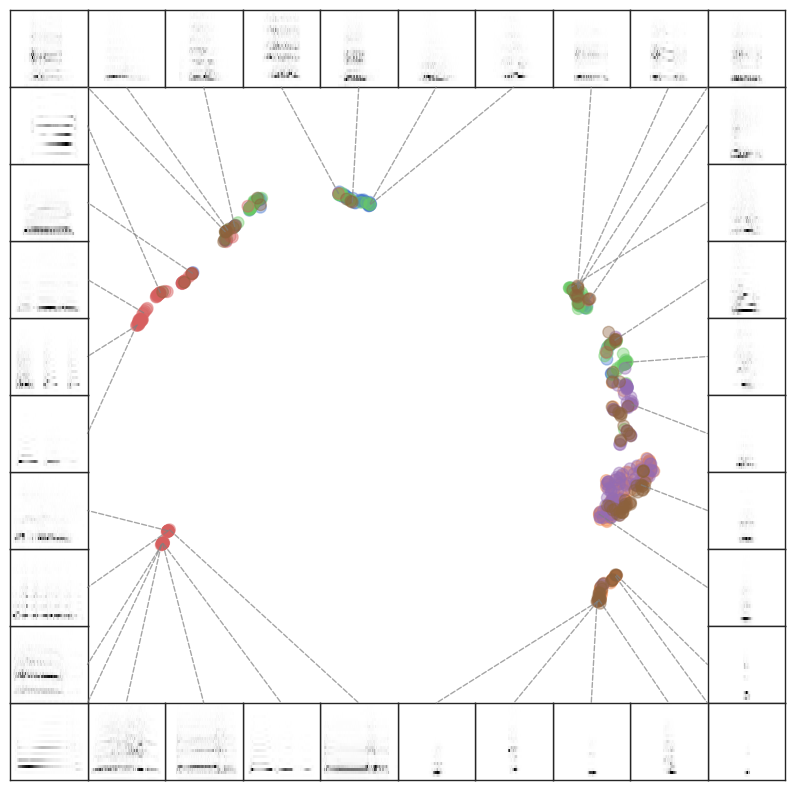

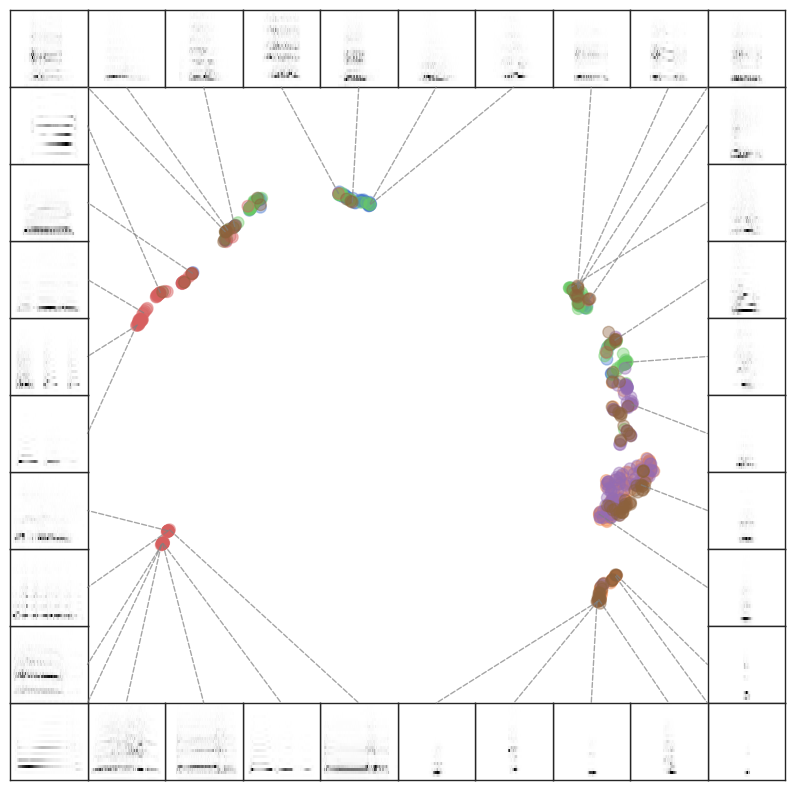

In [304]:
scatter_spec(
    vis_data_sub["embeddings"]["lfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


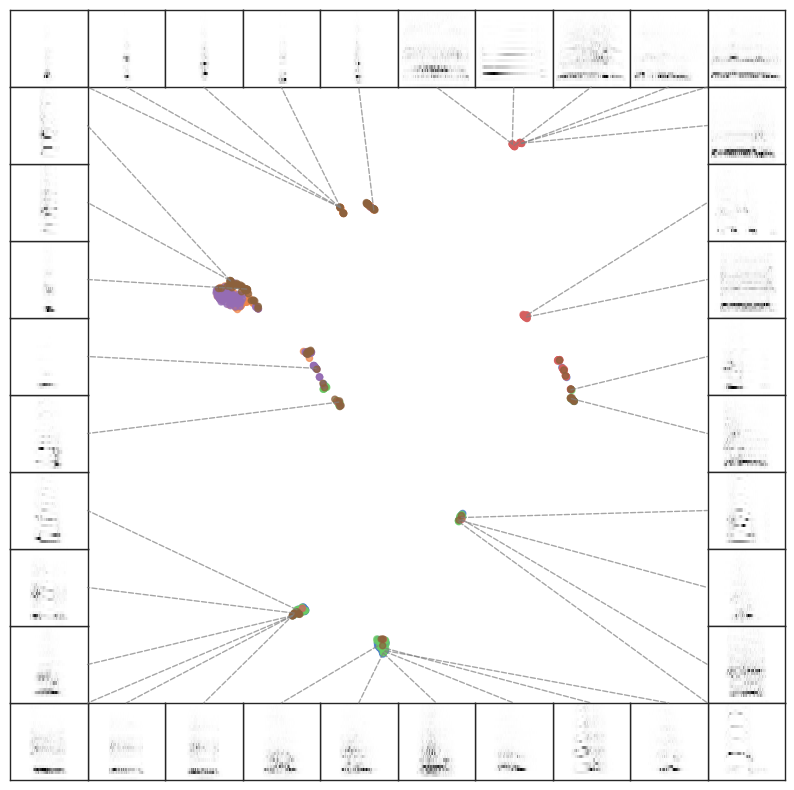

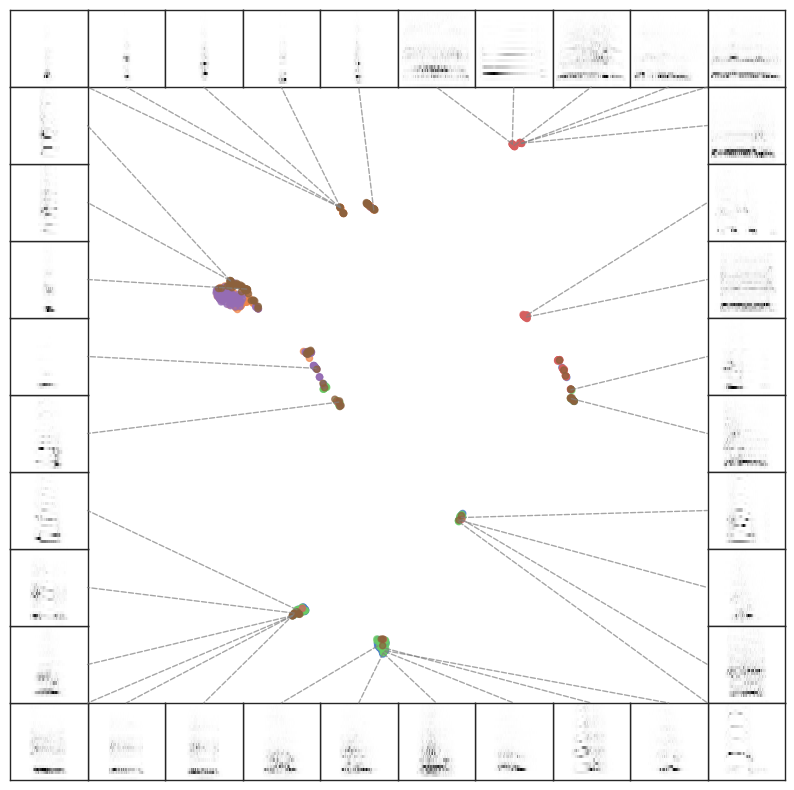

In [305]:
scatter_spec(
    vis_data_sub["embeddings"]["mfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.7, "s": 20, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


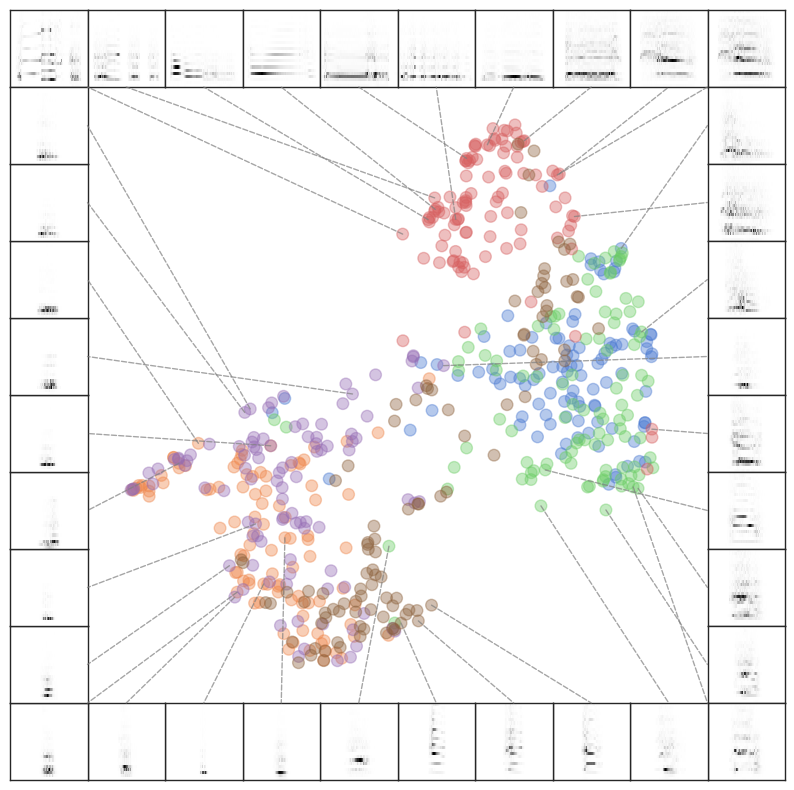

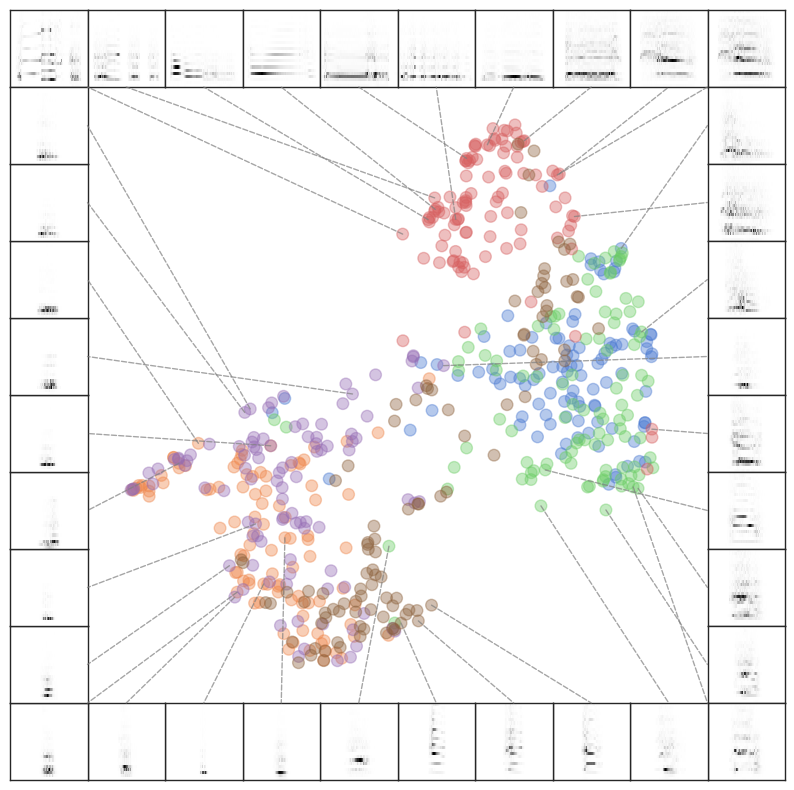

In [306]:
scatter_spec(
    vis_data_sub["embeddings"]["spec"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


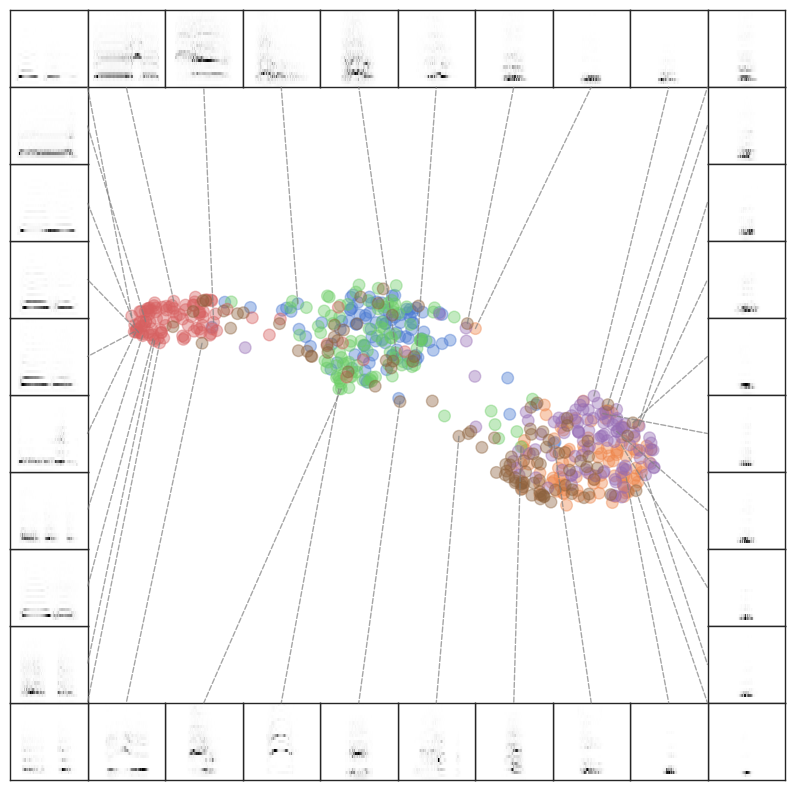

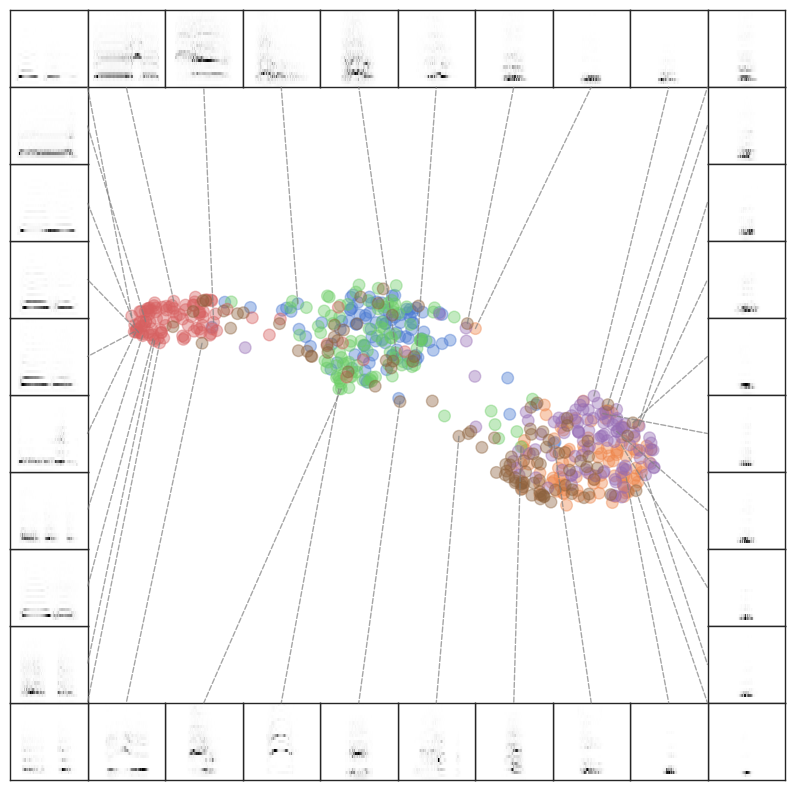

In [307]:
scatter_spec(
    vis_data_sub["embeddings"]["vae"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

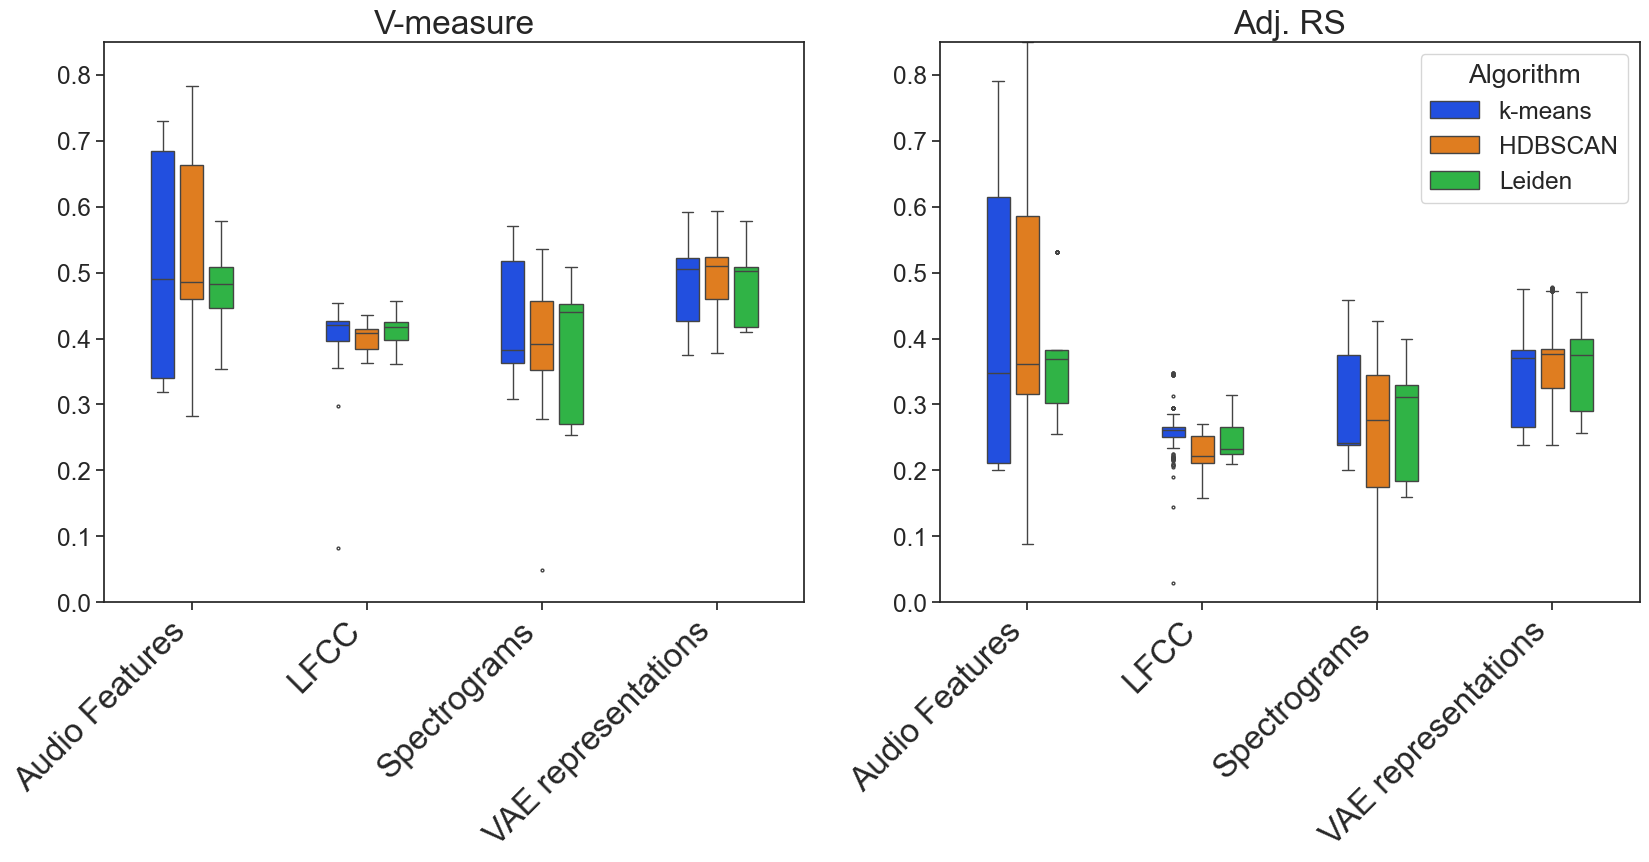

In [327]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.boxplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        gap=.2,
        fliersize=2,
        width=.5,
        palette="bright"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


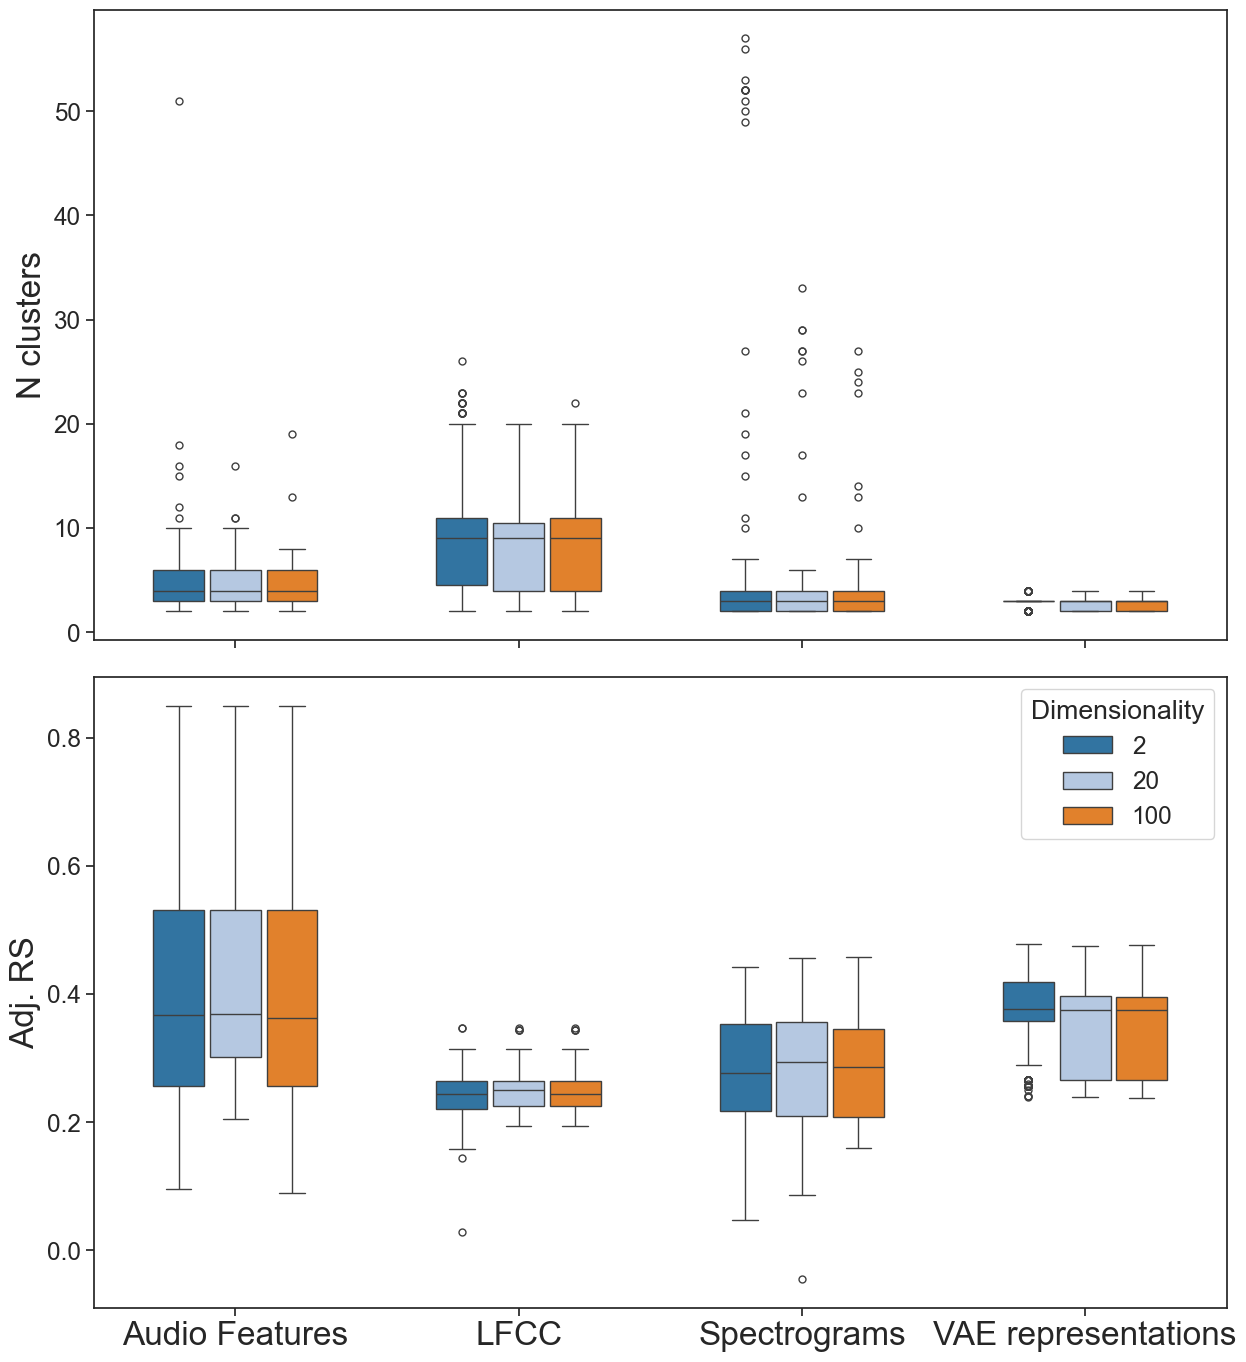

In [329]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Dimensionality", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


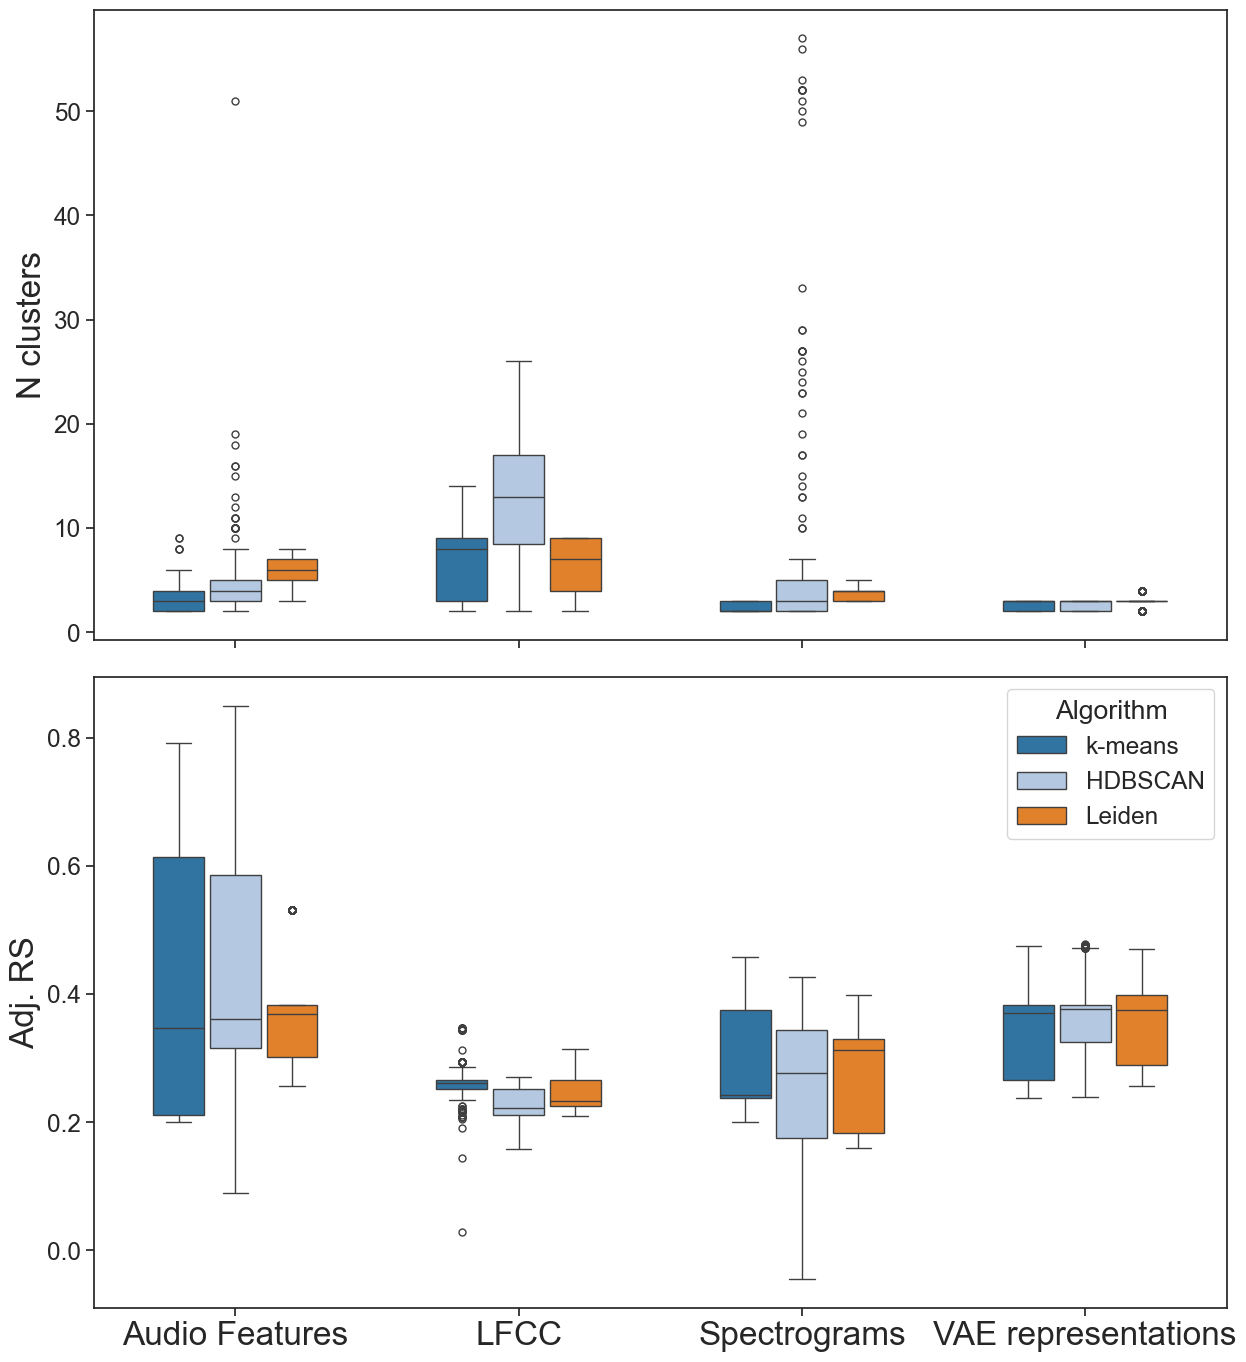

In [328]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


In [330]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(results_df[results_df["Representation"]==rep]["N clusters"].min())
    print(results_df[results_df["Representation"]==rep]["N clusters"].max())
    print(results_df[results_df["Representation"]==rep]["N clusters"].mean())
    print(results_df[results_df["Representation"]==rep]["N clusters"].std())

Audio Features
2
51
4.618300653594771
2.798780538218768
LFCC
2
26
8.652287581699346
5.106395294283602
Spectrogram
2
57
4.23921568627451
6.521131933009156
VAE
2
4
2.7594771241830065
0.5694488366411229


In [331]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(results_df[results_df["Algorithm"]==algo]["N clusters"].min())
    print(results_df[results_df["Algorithm"]==algo]["N clusters"].max())
    print(results_df[results_df["Algorithm"]==algo]["N clusters"].mean())
    print(results_df[results_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_df = results_df[results_df["Representation"]==rep]
        print(sub_df[(sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_df[(sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_df[(sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_df[(sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
16
4.68
3.369388468241902
  Audio Features
9
2
3.196078431372549
1.239437385749833
  LFCC
14
2
7.086274509803921
3.245895021604492
  Spectrogram
3
2
2.2862745098039214
0.4529081914246008
  VAE
3
2
2.619607843137255
0.4864379640320324
HDBSCAN
2
57
7.83843137254902
7.783002696611836
  Audio Features
51
2
4.764705882352941
3.889154287833224
  LFCC
26
2
12.254901960784315
6.3489199814846735
  Spectrogram
57
2
6.67843137254902
10.819134291663964
  VAE
3
2
2.6823529411764704
0.4664769459296302
Leiden
2
11
5.447843137254902
2.9208933882865074
  Audio Features
8
3
5.894117647058824
1.7925273325874789
  LFCC
9
2
6.6156862745098035
2.816107532299199
  Spectrogram
5
3
3.7529411764705882
0.7822723162947351
  VAE
4
2
2.976470588235294
0.6695245214041556


In [332]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(results_df[results_df["Algorithm"]==algo]["Adj. RS"].min())
    print(results_df[results_df["Algorithm"]==algo]["Adj. RS"].max())
    print(results_df[results_df["Algorithm"]==algo]["Adj. RS"].mean())
    print(results_df[results_df["Algorithm"]==algo]["Adj. RS"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_df = results_df[results_df["Representation"]==rep]
        print(sub_df[(sub_df["Algorithm"]==algo)]["Adj. RS"].max())
        print(sub_df[(sub_df["Algorithm"]==algo)]["Adj. RS"].min())
        print(sub_df[(sub_df["Algorithm"]==algo)]["Adj. RS"].mean())
        print(sub_df[(sub_df["Algorithm"]==algo)]["Adj. RS"].std())

k-means
0.028466224755781953
0.7913694430046565
0.3113513271526837
0.11505281737433745
  Audio Features
0.7913694430046565
0.20090604457320374
0.39588223984557713
0.1834078904020717
  LFCC
0.3471105077654122
0.028466224755781953
0.260867249729986
0.03275232833456728
  Spectrogram
0.45812051357926287
0.20067084391232443
0.29462912692997434
0.09165442379315873
  VAE
0.4754255568808261
0.23799496937676037
0.36226983583114514
0.07443695208147205
HDBSCAN
-0.04480083047849346
0.8499394886191471
0.29946976247663376
0.11951152135011611
  Audio Features
0.8499394886191471
0.08903371749334772
0.4075718163194785
0.17220022028205875
  LFCC
0.269754336201843
0.15847298039612848
0.2272830742793487
0.021214005031586377
  Spectrogram
0.4269007153456658
-0.04480083047849346
0.261120473794331
0.09089877408728668
  VAE
0.478012621495879
0.2387388241376128
0.36807266423235585
0.07187755781172159
Leiden
0.1589548095762525
0.5308940643903112
0.3112224016202388
0.0879023612984563
  Audio Features
0.530894064